In [2]:
import numpy as np
import matplotlib.pyplot as plt
import glob
from scipy.linalg import sqrtm
from pathlib import Path

def load_npy(root_folder):
    root = Path(root_folder)
    arrays = []

    for file in root.rglob("*.npy"):   # recursively finds all .npy files
        arr = np.load(file)
        arrays.append(arr)

    return arrays
colors = ['blue', 'orange', 'green']

Using least squares estimator and averaging over many different choices of parameter vectors

Data trotter least squares 1

In [2]:
data_1_ls = load_npy('C:/Users/alexg/python_scripts/corrected_FI_code/trotter_least_squares/data_trotter_least_squares_0.01/data_trotter_1_least_squares')
print(len(data_1_ls))

280


In [13]:
print("Runtime: ", np.max(np.sum([data_1_ls[12+i*14] for i in range(20)], axis = 1)/3600), " hours")

Runtime:  3.3572980055544113  hours


In [4]:
infidelity = [data_1_ls[9+i*14] for i in range(20)]
inv_fisher_trace = [data_1_ls[6+i*14] for i in range(20)]
mse = [np.sum(data_1_ls[11+i*14], axis = 1) for i in range(20)]
log_det_fisher = [np.log(np.linalg.det(data_1_ls[5+i*14])) for i in range(20)]
bias = [data_1_ls[1+i*14] for i in range(20)]
CRB_diff_eig = [data_1_ls[4+i*14] for i in range(20)]
beta = data_1_ls[0]

mean_infidelity = np.mean(infidelity, axis=0)
std_infidelity = np.std(infidelity, axis=0)
mean_inv_fisher_trace = np.mean(inv_fisher_trace, axis=0)
std_inv_fisher_trace = np.std(inv_fisher_trace, axis=0)
mean_mse = np.mean(mse, axis=0)
std_mse = np.std(mse, axis=0)
mean_log_det_fisher = np.mean(log_det_fisher, axis=0)
std_log_det_fisher = np.std(log_det_fisher, axis=0)
mean_bias = np.mean(bias, axis=0)
std_bias = np.std(bias, axis=0)
mean_CRB_diff_eig = np.mean(CRB_diff_eig, axis=0)
std_CRB_diff_eig = np.std(CRB_diff_eig, axis=0)

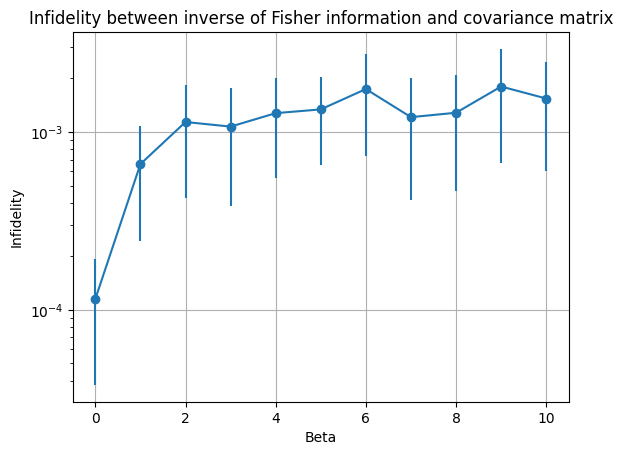

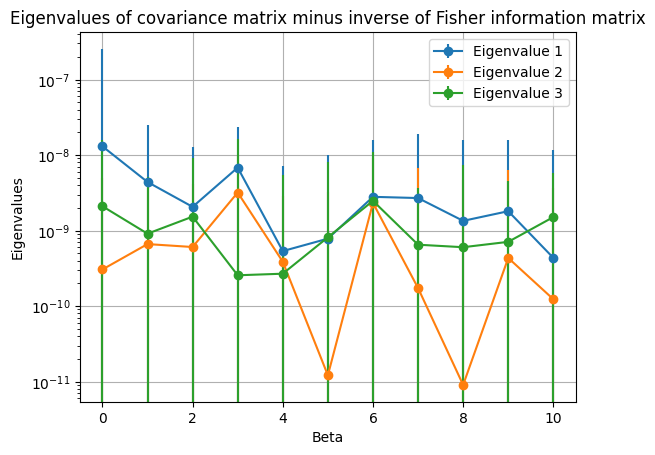

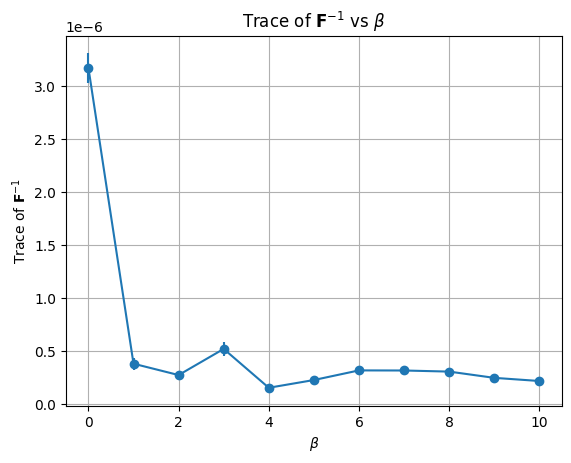

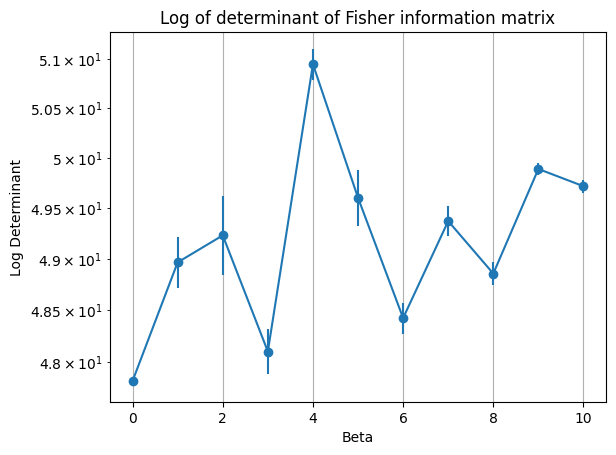

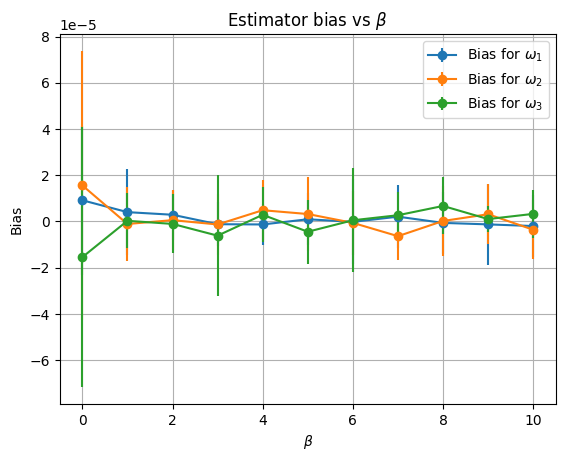

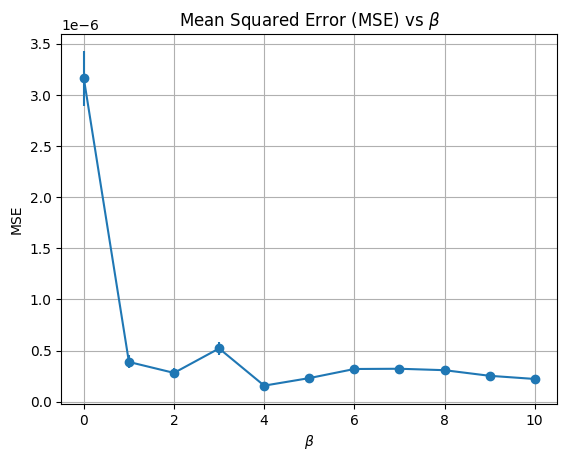

In [11]:
plt.errorbar(beta, mean_infidelity, yerr=std_infidelity, marker='o')
plt.semilogy()
#plt.semilogx()
plt.xlabel("Beta")
plt.ylabel("Infidelity")
plt.title("Infidelity between inverse of Fisher information and covariance matrix")
plt.grid()
plt.show()

plt.errorbar(beta, np.abs([x[0] for x in mean_CRB_diff_eig]), yerr=[x[0] for x in std_CRB_diff_eig], marker = 'o', label = "Eigenvalue 1")
plt.errorbar(beta, np.abs([x[1] for x in mean_CRB_diff_eig]), yerr=[x[1] for x in std_CRB_diff_eig], marker = 'o', label = "Eigenvalue 2")
plt.errorbar(beta, np.abs([x[2] for x in mean_CRB_diff_eig]), yerr=[x[2] for x in std_CRB_diff_eig], marker = 'o', label = "Eigenvalue 3")
plt.legend()
plt.semilogy()
#plt.semilogx()
plt.xlabel("Beta")
plt.ylabel("Eigenvalues")
plt.title("Eigenvalues of covariance matrix minus inverse of Fisher information matrix")
plt.grid()
plt.show()

plt.errorbar(beta, mean_inv_fisher_trace, yerr=std_inv_fisher_trace, marker='o')
#plt.semilogy()
#plt.semilogx()
plt.xlabel("$\\beta$")
plt.ylabel("Trace of $\mathbf{F}^{-1}$")
plt.title("Trace of $\mathbf{F}^{-1}$ vs $\\beta$")
plt.grid()
plt.show()

plt.errorbar(beta, mean_log_det_fisher, yerr=std_log_det_fisher, marker='o')
plt.semilogy()
#plt.semilogx()
plt.xlabel("Beta")
plt.ylabel("Log Determinant")
plt.title("Log of determinant of Fisher information matrix")
plt.grid()
plt.show()

for i in range(mean_bias.shape[1]):
    plt.errorbar(beta, mean_bias[:,i], yerr = std_bias[:,i], label = f"Bias for $\omega_{i+1}$", marker = 'o')
#plt.semilogx()
plt.xlabel("$\\beta$")
plt.ylabel("Bias")
plt.title("Estimator bias vs $\\beta$")
plt.legend()
plt.grid()
plt.show()

plt.errorbar(beta, mean_mse, yerr=std_mse, marker = 'o')
plt.xlabel("$\\beta$")
plt.ylabel("MSE")
#plt.semilogy()
plt.title("Mean Squared Error (MSE) vs $\\beta$")
plt.grid()
plt.show()

Data trotter least squares 2 (Using $\vec{\omega} = \vec{0}$ as inital guess for least squares)

In [6]:
data_2_ls = load_npy('C:/Users/alexg/python_scripts/corrected_FI_code/trotter_least_squares/data_trotter_least_squares_0.01/data_trotter_2_least_squares')
print(len(data_2_ls))

280


In [7]:
print("Runtime: ", np.max(np.sum([data_2_ls[12+i*14] for i in range(20)], axis = 1))/3600, "hours")

Runtime:  3.224592246744368 hours


In [ ]:
infidelity = [data_2_ls[9+i*14] for i in range(20)]
inv_fisher_trace = [data_2_ls[6+i*14] for i in range(20)]
mse = [np.sum(data_2_ls[11+i*14], axis = 1) for i in range(20)]
log_det_fisher = [np.log(np.linalg.det(data_2_ls[5+i*14])) for i in range(20)]
bias = [data_2_ls[1+i*14] for i in range(20)]
CRB_diff_eig = [data_2_ls[4+i*14] for i in range(20)]
beta = data_2_ls[0]

mean_infidelity = np.mean(infidelity, axis=0)
std_infidelity = np.std(infidelity, axis=0)
mean_inv_fisher_trace = np.mean(inv_fisher_trace, axis=0)
std_inv_fisher_trace = np.std(inv_fisher_trace, axis=0)
mean_mse = np.mean(mse, axis=0)
std_mse = np.std(mse, axis=0)
mean_log_det_fisher = np.mean(log_det_fisher, axis=0)
std_log_det_fisher = np.std(log_det_fisher, axis=0)
mean_bias = np.mean(bias, axis=0)
std_bias = np.std(bias, axis=0)
mean_CRB_diff_eig = np.mean(CRB_diff_eig, axis=0)
std_CRB_diff_eig = np.std(CRB_diff_eig, axis=0)

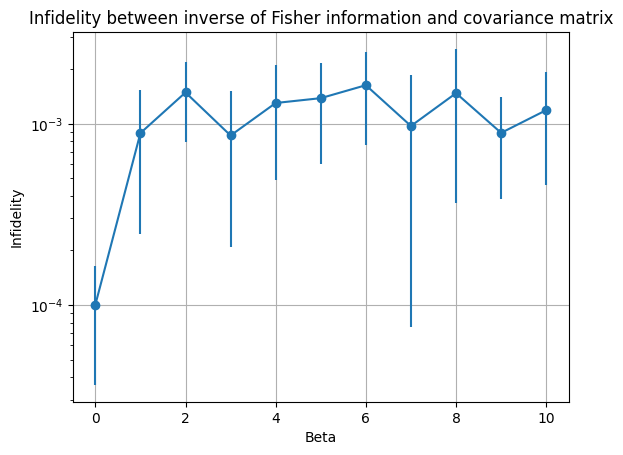

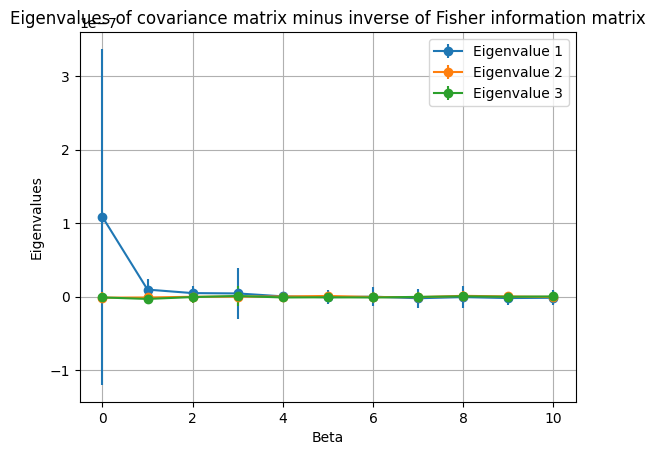

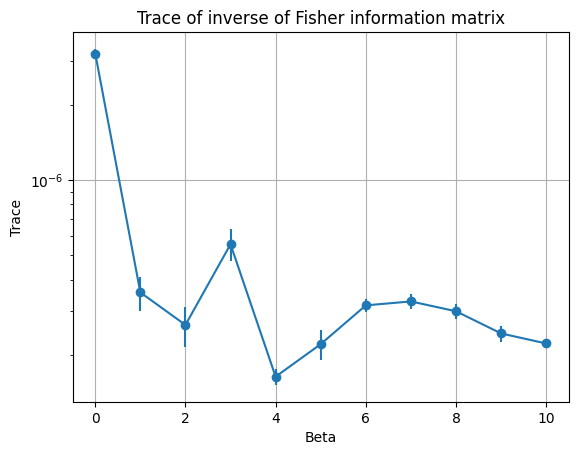

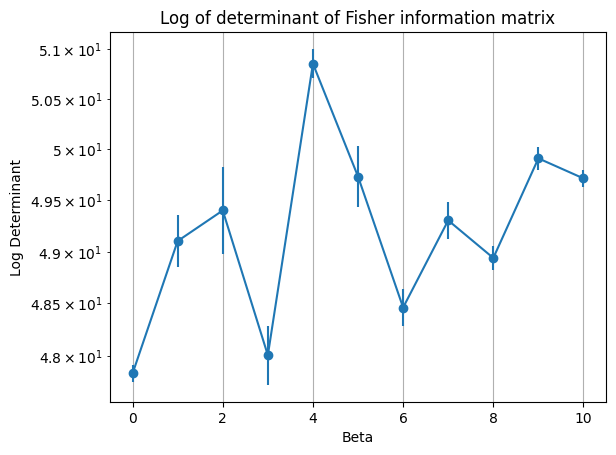

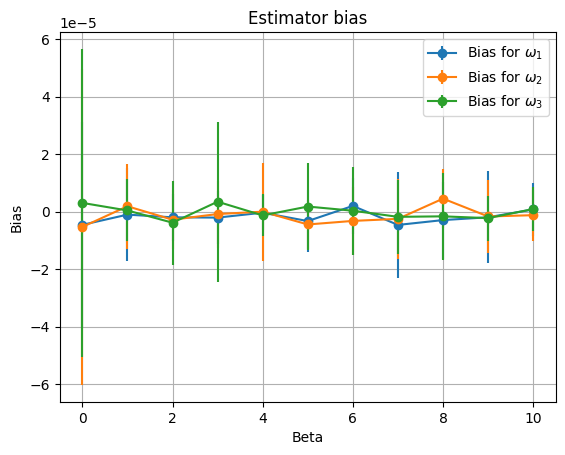

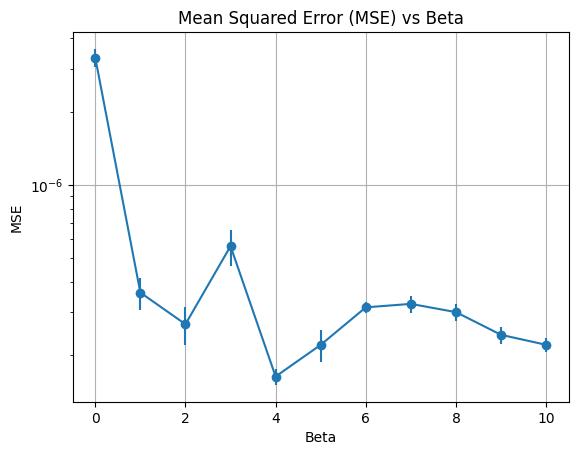

In [9]:
plt.errorbar(beta, mean_infidelity, yerr=std_infidelity, marker='o')
plt.semilogy()
#plt.semilogx()
plt.xlabel("Beta")
plt.ylabel("Infidelity")
plt.title("Infidelity between inverse of Fisher information and covariance matrix")
plt.grid()
plt.show()

plt.errorbar(beta, [x[0] for x in mean_CRB_diff_eig], yerr=[x[0] for x in std_CRB_diff_eig], marker = 'o', label = "Eigenvalue 1")
plt.errorbar(beta, [x[1] for x in mean_CRB_diff_eig], yerr=[x[1] for x in std_CRB_diff_eig], marker = 'o', label = "Eigenvalue 2")
plt.errorbar(beta, [x[2] for x in mean_CRB_diff_eig], yerr=[x[2] for x in std_CRB_diff_eig], marker = 'o', label = "Eigenvalue 3")
plt.legend()
#plt.semilogy()
#plt.semilogx()
plt.xlabel("Beta")
plt.ylabel("Eigenvalues")
plt.title("Eigenvalues of covariance matrix minus inverse of Fisher information matrix")
plt.grid()
plt.show()

plt.errorbar(beta, mean_inv_fisher_trace, yerr=std_inv_fisher_trace, marker='o')
plt.semilogy()
#plt.semilogx()
plt.xlabel("Beta")
plt.ylabel("Trace")
plt.title("Trace of inverse of Fisher information matrix")
plt.grid()
plt.show()

plt.errorbar(beta, mean_log_det_fisher, yerr=std_log_det_fisher, marker='o')
plt.semilogy()
#plt.semilogx()
plt.xlabel("Beta")
plt.ylabel("Log Determinant")
plt.title("Log of determinant of Fisher information matrix")
plt.grid()
plt.show()

for i in range(mean_bias.shape[1]):
    plt.errorbar(beta, mean_bias[:,i], yerr = std_bias[:,i], label = f"Bias for $\omega_{i+1}$", marker = 'o')
#plt.semilogx()
plt.xlabel("Beta")
plt.ylabel("Bias")
plt.title("Estimator bias")
plt.legend()
plt.grid()
plt.show()

plt.errorbar(beta, mean_mse, yerr=std_mse, marker = 'o')
plt.xlabel("Beta")
plt.ylabel("MSE")
plt.semilogy()
plt.title("Mean Squared Error (MSE) vs Beta")
plt.grid()
plt.show()

Data trotter least squares 3

In [10]:
data_3_ls = load_npy('C:/Users/alexg/python_scripts/corrected_FI_code/trotter_least_squares/data_trotter_least_squares_0.01/data_trotter_3_least_squares')
print(len(data_3_ls))

280


In [17]:
print("Runtime: ", np.max(np.sum([data_3_ls[12+i*14] for i in range(20)], axis = 1)/3600), "hours")

Runtime:  2.7020537833372753 hours


In [12]:
infidelity = [data_3_ls[9+i*14] for i in range(20)]
inv_fisher_trace = [data_3_ls[6+i*14] for i in range(20)]
mse = [np.sum(data_3_ls[11+i*14], axis = 1) for i in range(20)]
log_det_fisher = [np.log(np.linalg.det(data_3_ls[5+i*14])) for i in range(20)]
bias = [data_3_ls[1+i*14] for i in range(20)]
CRB_diff_eig = [data_3_ls[4+i*14] for i in range(20)]
beta = data_3_ls[0]

mean_infidelity = np.mean(infidelity, axis=0)
std_infidelity = np.std(infidelity, axis=0)
mean_inv_fisher_trace = np.mean(inv_fisher_trace, axis=0)
std_inv_fisher_trace = np.std(inv_fisher_trace, axis=0)
mean_mse = np.mean(mse, axis=0)
std_mse = np.std(mse, axis=0)
mean_log_det_fisher = np.mean(log_det_fisher, axis=0)
std_log_det_fisher = np.std(log_det_fisher, axis=0)
mean_bias = np.mean(bias, axis=0)
std_bias = np.std(bias, axis=0)
mean_CRB_diff_eig = np.mean(CRB_diff_eig, axis=0)
std_CRB_diff_eig = np.std(CRB_diff_eig, axis=0)

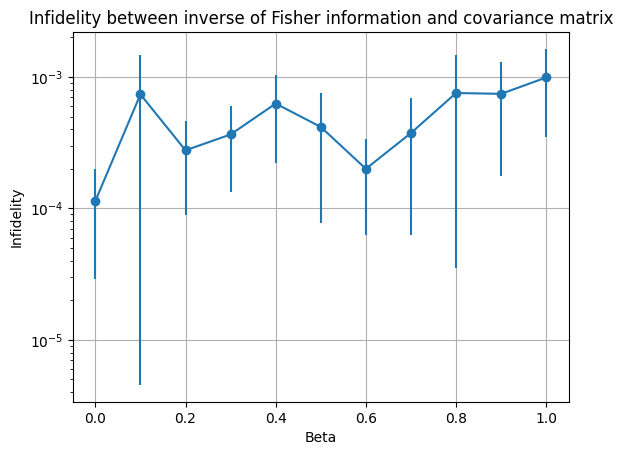

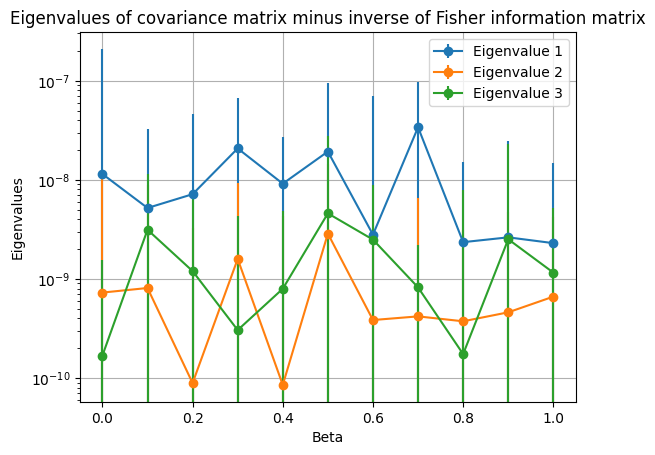

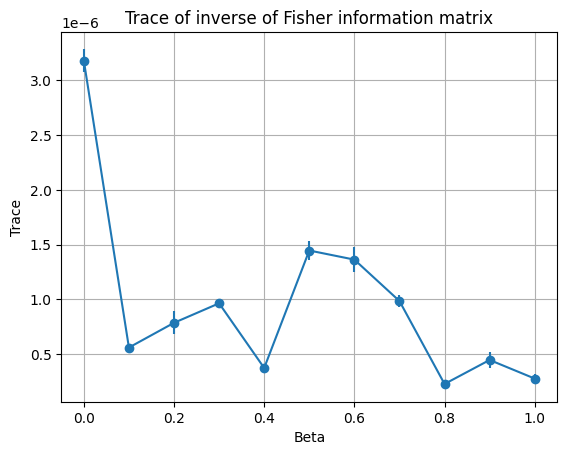

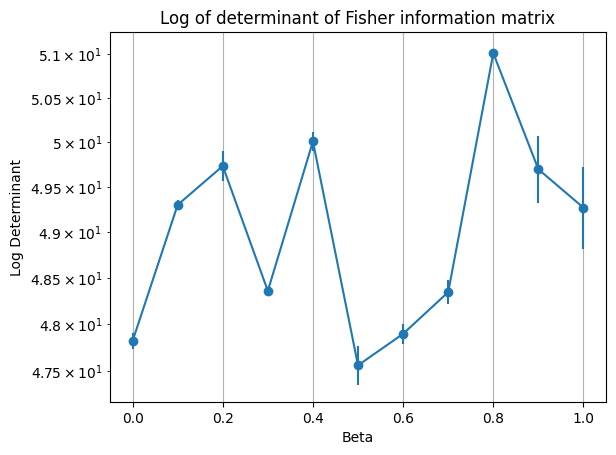

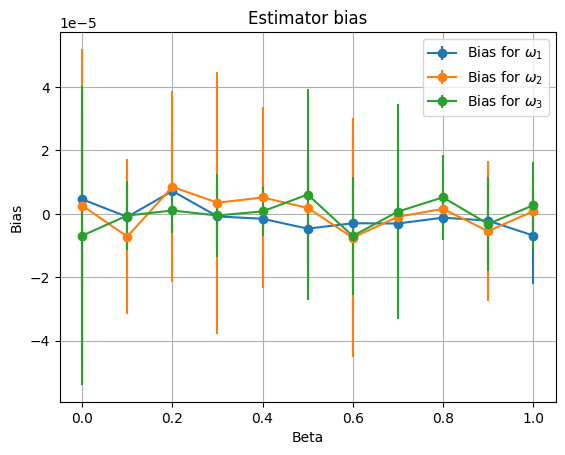

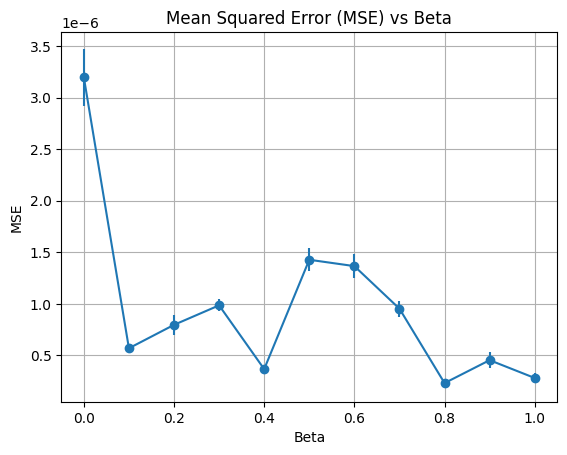

In [13]:
plt.errorbar(beta, mean_infidelity, yerr=std_infidelity, marker='o')
plt.semilogy()
#plt.semilogx()
plt.xlabel("Beta")
plt.ylabel("Infidelity")
plt.title("Infidelity between inverse of Fisher information and covariance matrix")
plt.grid()
plt.show()

plt.errorbar(beta, np.abs([x[0] for x in mean_CRB_diff_eig]), yerr=[x[0] for x in std_CRB_diff_eig], marker = 'o', label = "Eigenvalue 1")
plt.errorbar(beta, np.abs([x[1] for x in mean_CRB_diff_eig]), yerr=[x[1] for x in std_CRB_diff_eig], marker = 'o', label = "Eigenvalue 2")
plt.errorbar(beta, np.abs([x[2] for x in mean_CRB_diff_eig]), yerr=[x[2] for x in std_CRB_diff_eig], marker = 'o', label = "Eigenvalue 3")
plt.legend()
plt.semilogy()
#plt.semilogx()
plt.xlabel("Beta")
plt.ylabel("Eigenvalues")
plt.title("Eigenvalues of covariance matrix minus inverse of Fisher information matrix")
plt.grid()
plt.show()

plt.errorbar(beta, mean_inv_fisher_trace, yerr=std_inv_fisher_trace, marker='o')
#plt.semilogy()
#plt.semilogx()
plt.xlabel("Beta")
plt.ylabel("Trace")
plt.title("Trace of inverse of Fisher information matrix")
plt.grid()
plt.show()

plt.errorbar(beta, mean_log_det_fisher, yerr=std_log_det_fisher, marker='o')
plt.semilogy()
#plt.semilogx()
plt.xlabel("Beta")
plt.ylabel("Log Determinant")
plt.title("Log of determinant of Fisher information matrix")
plt.grid()
plt.show()

for i in range(mean_bias.shape[1]):
    plt.errorbar(beta, mean_bias[:,i], yerr = std_bias[:,i], label = f"Bias for $\omega_{i+1}$", marker = 'o')
#plt.semilogx()
plt.xlabel("Beta")
plt.ylabel("Bias")
plt.title("Estimator bias")
plt.legend()
plt.grid()
plt.show()

plt.errorbar(beta, mean_mse, yerr=std_mse, marker = 'o')
plt.xlabel("Beta")
plt.ylabel("MSE")
#plt.semilogy()
plt.title("Mean Squared Error (MSE) vs Beta")
plt.grid()
plt.show()

Data trotter least squares fibonacci lattice 0

In [14]:
data_0_fl = load_npy('C:/Users/alexg/python_scripts/corrected_FI_code/protocol_B/least_squares/data_0_protocol_B_fl_least_squares')
print(len(data_0_fl))

280


In [16]:
print("Runtime: ", np.max(np.sum([data_0_fl[12+i*14] for i in range(20)], axis = 1))/3600, "hours")

Runtime:  1.2792643045054541 hours


In [19]:
infidelity = [data_0_fl[8+i*14] for i in range(20)]
inv_fisher_trace = [data_0_fl[5+i*14] for i in range(20)]
mse = [np.sum(data_0_fl[10+i*14], axis = 1) for i in range(20)]
log_det_fisher = [np.log(np.linalg.det(data_0_fl[4+i*14])) for i in range(20)]
bias = [data_0_fl[i*14] for i in range(20)]
CRB_diff_eig = [data_0_fl[3+i*14] for i in range(20)]
N_points = data_0_fl[11]

mean_infidelity = np.mean(infidelity, axis=0)
std_infidelity = np.std(infidelity, axis=0)
mean_inv_fisher_trace = np.mean(inv_fisher_trace, axis=0)
std_inv_fisher_trace = np.std(inv_fisher_trace, axis=0)
mean_mse = np.mean(mse, axis=0)
std_mse = np.std(mse, axis=0)
mean_log_det_fisher = np.mean(log_det_fisher, axis=0)
std_log_det_fisher = np.std(log_det_fisher, axis=0)
mean_bias = np.mean(bias, axis=0)
std_bias = np.std(bias, axis=0)
mean_CRB_diff_eig = np.mean(CRB_diff_eig, axis=0)
std_CRB_diff_eig = np.std(CRB_diff_eig, axis=0)

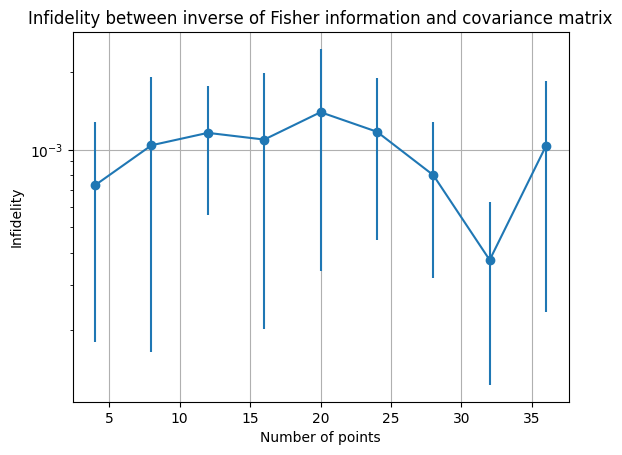

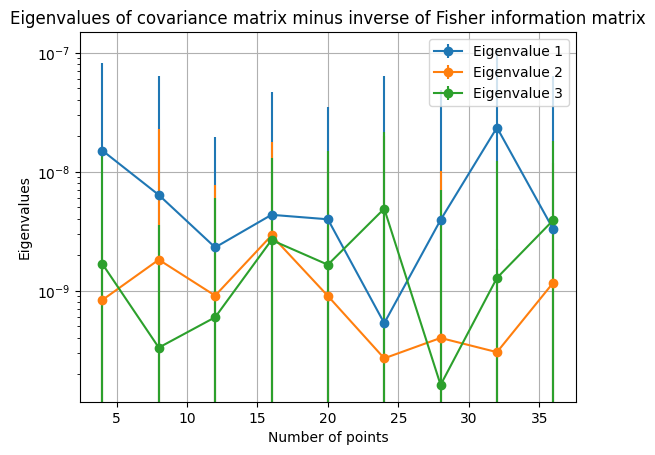

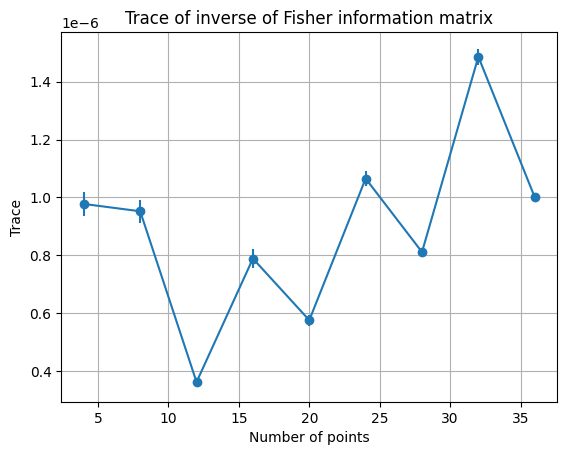

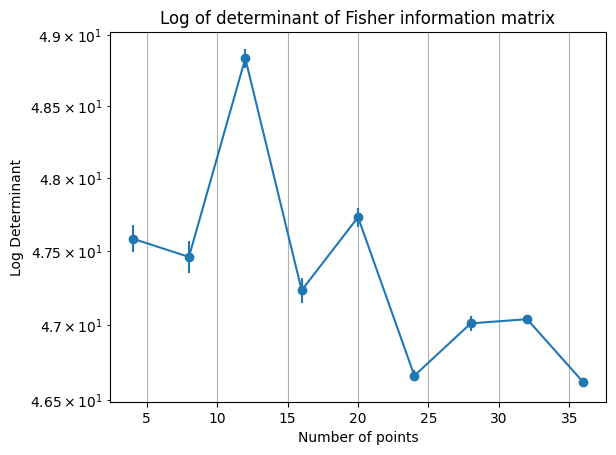

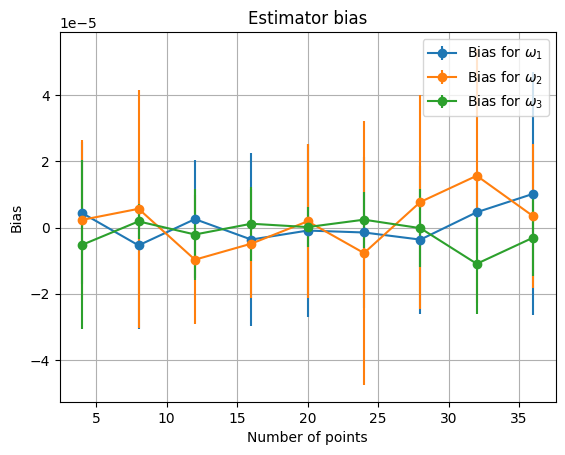

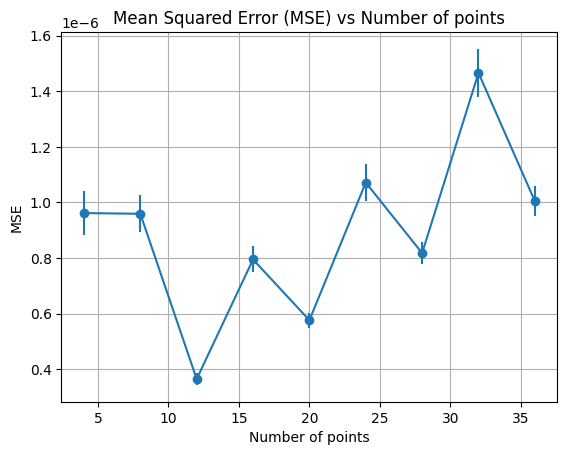

In [20]:
plt.errorbar(N_points, mean_infidelity, yerr=std_infidelity, marker='o')
plt.semilogy()
#plt.semilogx()
plt.xlabel("Number of points")
plt.ylabel("Infidelity")
plt.title("Infidelity between inverse of Fisher information and covariance matrix")
plt.grid()
plt.show()

plt.errorbar(N_points, np.abs([x[0] for x in mean_CRB_diff_eig]), yerr=[x[0] for x in std_CRB_diff_eig], marker = 'o', label = "Eigenvalue 1")
plt.errorbar(N_points, np.abs([x[1] for x in mean_CRB_diff_eig]), yerr=[x[1] for x in std_CRB_diff_eig], marker = 'o', label = "Eigenvalue 2")
plt.errorbar(N_points, np.abs([x[2] for x in mean_CRB_diff_eig]), yerr=[x[2] for x in std_CRB_diff_eig], marker = 'o', label = "Eigenvalue 3")
plt.legend()
plt.semilogy()
#plt.semilogx()
plt.xlabel("Number of points")
plt.ylabel("Eigenvalues")
plt.title("Eigenvalues of covariance matrix minus inverse of Fisher information matrix")
plt.grid()
plt.show()

plt.errorbar(N_points, mean_inv_fisher_trace, yerr=std_inv_fisher_trace, marker='o')
#plt.semilogy()
#plt.semilogx()
plt.xlabel("Number of points")
plt.ylabel("Trace")
plt.title("Trace of inverse of Fisher information matrix")
plt.grid()
plt.show()

plt.errorbar(N_points, mean_log_det_fisher, yerr=std_log_det_fisher, marker='o')
plt.semilogy()
#plt.semilogx()
plt.xlabel("Number of points")
plt.ylabel("Log Determinant")
plt.title("Log of determinant of Fisher information matrix")
plt.grid()
plt.show()

for i in range(mean_bias.shape[1]):
    plt.errorbar(N_points, mean_bias[:,i], yerr = std_bias[:,i], label = f"Bias for $\omega_{i+1}$", marker = 'o')
#plt.semilogx()
plt.xlabel("Number of points")
plt.ylabel("Bias")
plt.title("Estimator bias")
plt.legend()
plt.grid()
plt.show()

plt.errorbar(N_points, mean_mse, yerr=std_mse, marker = 'o')
plt.xlabel("Number of points")
plt.ylabel("MSE")
#plt.semilogy()
plt.title("Mean Squared Error (MSE) vs Number of points")
plt.grid()
plt.show()

Data trotter least squares 4 ($\beta$ = 0)

In [47]:
data_4_ls = load_npy('C:/Users/alexg/python_scripts/corrected_FI_code/trotter_least_squares/data_trotter_least_squares_0.01/data_trotter_4_least_squares')
print(len(data_4_ls))
print("Runtime: ", np.max(np.sum([data_4_ls[11+i*14] for i in range(20)], axis = 1)/3600), "hours")


280
Runtime:  2.0302305993768903 hours


In [62]:
delta_w = np.sqrt(data_4_ls[13][0])
w = np.array([-0.00496538, -0.01560312, 0.00275173])
print(delta_w/w)

delta_b = np.sqrt(np.array([1.6e-15,0.42e-15,0.24e-15]))
b = np.array([910e-9, 285e-9, 540e-9])
print(delta_b/b)

[-0.01394306 -0.00785084  0.04232471]
[0.04395604 0.07190843 0.02868877]


In [60]:
infidelity = [data_4_ls[8+i*14] for i in range(20)]
inv_fisher_trace = [data_4_ls[5+i*14] for i in range(20)]
mse = [np.sum(data_4_ls[10+i*14], axis = 1) for i in range(20)]
log_det_fisher = [np.log(np.linalg.det(data_4_ls[4+i*14])) for i in range(20)]
bias = [data_4_ls[i*14] for i in range(20)]
CRB_diff_eig = [data_4_ls[3+i*14] for i in range(20)]
sn_sd_var = data_4_ls[12]**2

mean_infidelity = np.mean(infidelity, axis=0)
std_infidelity = np.std(infidelity, axis=0)
mean_inv_fisher_trace = np.mean(inv_fisher_trace, axis=0)
std_inv_fisher_trace = np.std(inv_fisher_trace, axis=0)
mean_mse = np.mean(mse, axis=0)
std_mse = np.std(mse, axis=0)
mean_log_det_fisher = np.mean(log_det_fisher, axis=0)
std_log_det_fisher = np.std(log_det_fisher, axis=0)
mean_bias = np.mean(bias, axis=0)
std_bias = np.std(bias, axis=0)
mean_CRB_diff_eig = np.mean(CRB_diff_eig, axis=0)
std_CRB_diff_eig = np.std(CRB_diff_eig, axis=0)


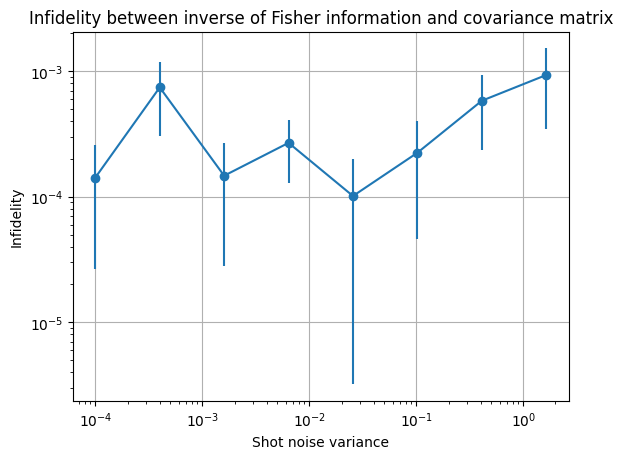

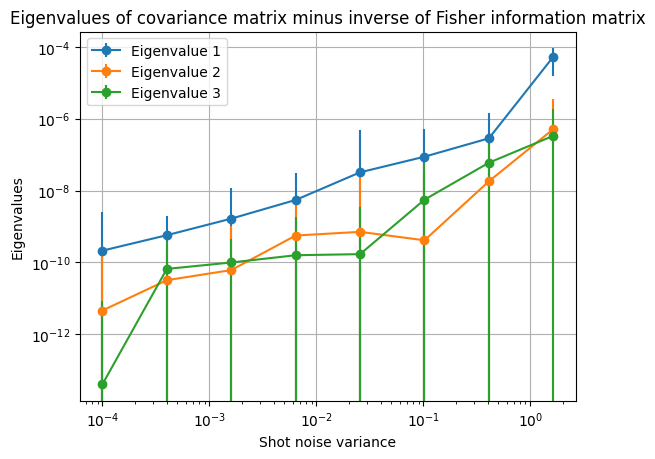

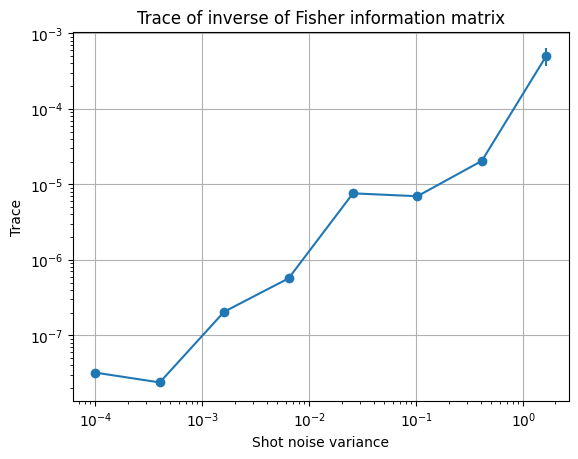

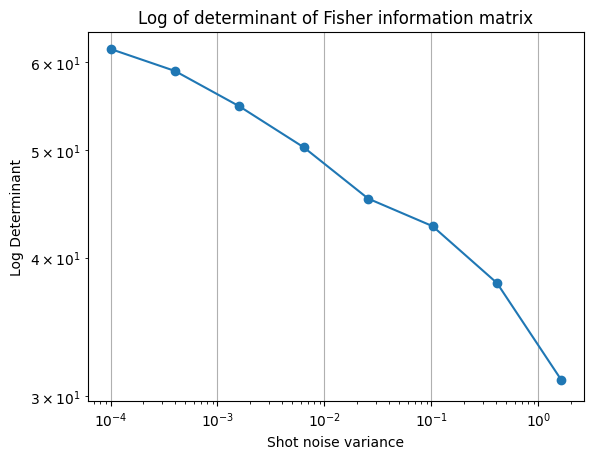

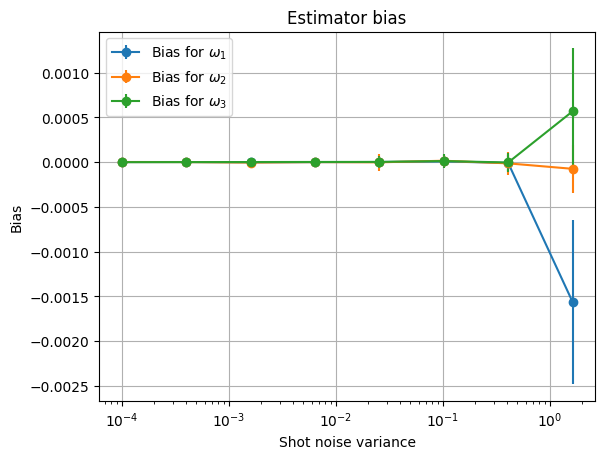

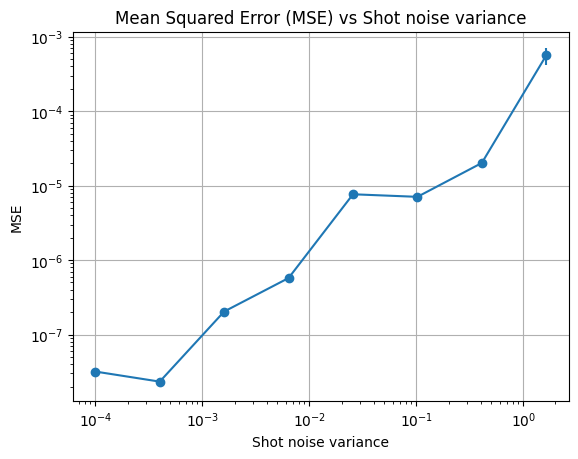

In [49]:
plt.errorbar(sn_sd_var, mean_infidelity, yerr=std_infidelity, marker='o')
plt.semilogy()
plt.semilogx()
plt.xlabel("Shot noise variance")
plt.ylabel("Infidelity")
plt.title("Infidelity between inverse of Fisher information and covariance matrix")
plt.grid()
plt.show()

plt.errorbar(sn_sd_var, np.abs([x[0] for x in mean_CRB_diff_eig]), yerr=[x[0] for x in std_CRB_diff_eig], marker = 'o', label = "Eigenvalue 1")
plt.errorbar(sn_sd_var, np.abs([x[1] for x in mean_CRB_diff_eig]), yerr=[x[1] for x in std_CRB_diff_eig], marker = 'o', label = "Eigenvalue 2")
plt.errorbar(sn_sd_var, np.abs([x[2] for x in mean_CRB_diff_eig]), yerr=[x[2] for x in std_CRB_diff_eig], marker = 'o', label = "Eigenvalue 3")
plt.legend()
plt.semilogy()
plt.semilogx()
plt.xlabel("Shot noise variance")
plt.ylabel("Eigenvalues")
plt.title("Eigenvalues of covariance matrix minus inverse of Fisher information matrix")
plt.grid()
plt.show()

plt.errorbar(sn_sd_var, mean_inv_fisher_trace, yerr=std_inv_fisher_trace, marker='o')
plt.semilogy()
plt.semilogx()
plt.xlabel("Shot noise variance")
plt.ylabel("Trace")
plt.title("Trace of inverse of Fisher information matrix")
plt.grid()
plt.show()

plt.errorbar(sn_sd_var, mean_log_det_fisher, yerr=std_log_det_fisher, marker='o')
plt.semilogy()
plt.semilogx()
plt.xlabel("Shot noise variance")
plt.ylabel("Log Determinant")
plt.title("Log of determinant of Fisher information matrix")
plt.grid()
plt.show()

for i in range(mean_bias.shape[1]):
    plt.errorbar(sn_sd_var, mean_bias[:,i], yerr = std_bias[:,i], label = f"Bias for $\omega_{i+1}$", marker = 'o')
plt.semilogx()
plt.xlabel("Shot noise variance")
plt.ylabel("Bias")
plt.title("Estimator bias")
plt.legend()
plt.grid()
plt.show()

plt.errorbar(sn_sd_var, mean_mse, yerr=std_mse, marker = 'o')
plt.xlabel("Shot noise variance")
plt.ylabel("MSE")
plt.semilogy()
plt.semilogx()
plt.title("Mean Squared Error (MSE) vs Shot noise variance")
plt.grid()
plt.show()

In [61]:
np.polyfit(sn_sd_var, mean_mse, deg = 1, full=True)

(array([ 3.36957598e-04, -1.75682580e-05]),
 array([1.22443349e-08]),
 2,
 array([1.2068258 , 0.73727302]),
 1.7763568394002505e-15)

Data trotter least squares 5 ($\beta$ = 1)

In [4]:
data_5_ls = load_npy('C:/Users/alexg/python_scripts/corrected_FI_code/trotter_least_squares/data_trotter_least_squares_0.01/data_trotter_5_least_squares')
print(len(data_5_ls))
print("Runtime: ", np.max(np.sum([data_5_ls[11+i*14] for i in range(20)], axis = 1)/3600), "hours")

280
Runtime:  1.9602981623676088 hours


In [5]:
delta_w = np.sqrt(data_5_ls[13][0])
w = np.array([0.02097122, -0.00928613, 0.01860309])
print(delta_w/w)

delta_b = np.sqrt(np.array([1.6e-15,0.42e-15,0.24e-15]))
b = np.array([910e-9, 285e-9, 540e-9])
print(delta_b/b)

[ 0.00145195 -0.00399253  0.00231301]
[0.04395604 0.07190843 0.02868877]


In [6]:
infidelity = [data_5_ls[8+i*14] for i in range(20)]
inv_fisher_trace = [data_5_ls[5+i*14] for i in range(20)]
mse = [np.sum(data_5_ls[10+i*14], axis = 1) for i in range(20)]
log_det_fisher = [np.log(np.linalg.det(data_5_ls[4+i*14])) for i in range(20)]
bias = [data_5_ls[i*14] for i in range(20)]
CRB_diff_eig = [data_5_ls[3+i*14] for i in range(20)]
sn_sd_var = data_5_ls[12]**2

mean_infidelity = np.mean(infidelity, axis=0)
std_infidelity = np.std(infidelity, axis=0)
mean_inv_fisher_trace = np.mean(inv_fisher_trace, axis=0)
std_inv_fisher_trace = np.std(inv_fisher_trace, axis=0)
mean_mse = np.mean(mse, axis=0)
std_mse = np.std(mse, axis=0)
mean_log_det_fisher = np.mean(log_det_fisher, axis=0)
std_log_det_fisher = np.std(log_det_fisher, axis=0)
mean_bias = np.mean(bias, axis=0)
std_bias = np.std(bias, axis=0)
mean_CRB_diff_eig = np.mean(CRB_diff_eig, axis=0)
std_CRB_diff_eig = np.std(CRB_diff_eig, axis=0)


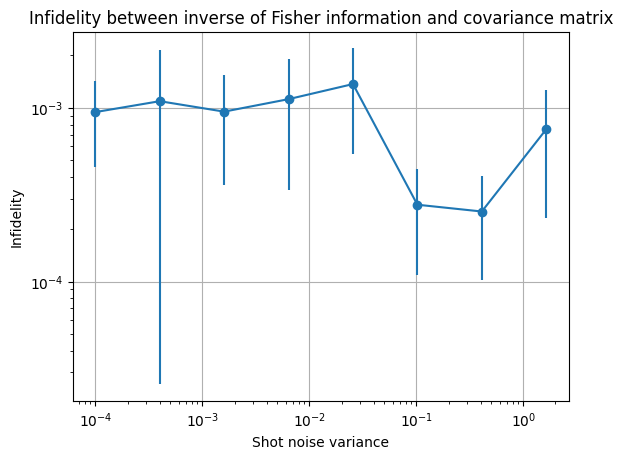

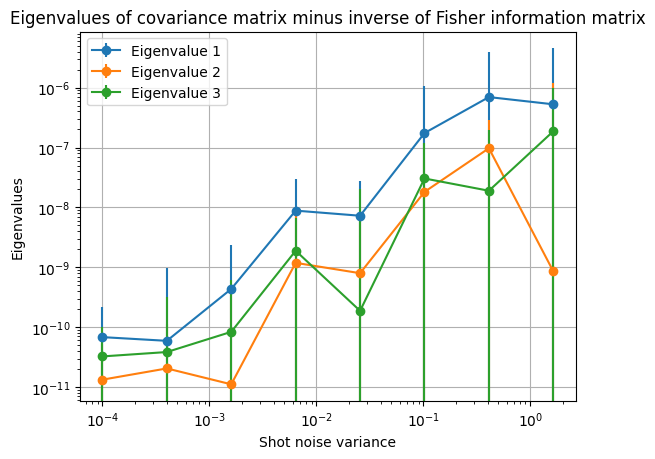

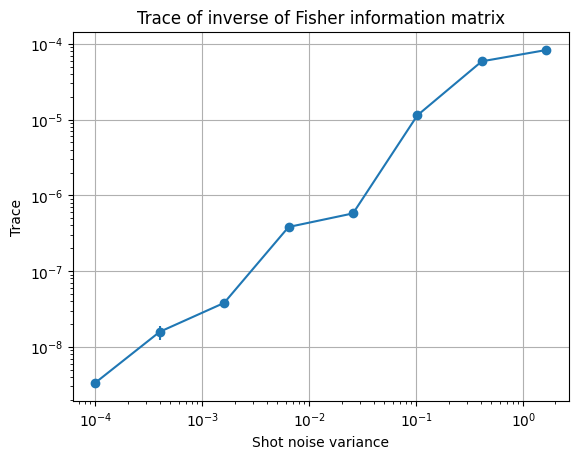

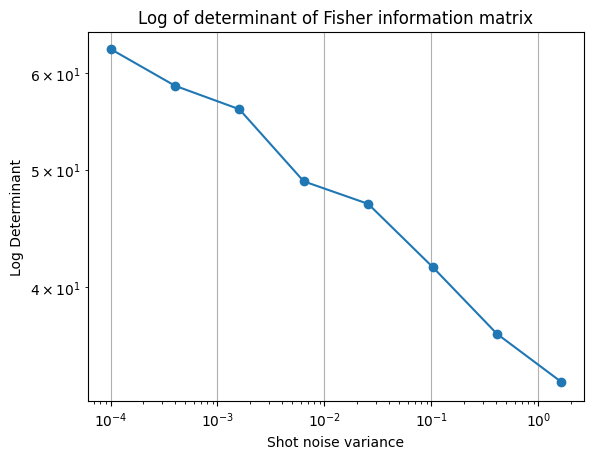

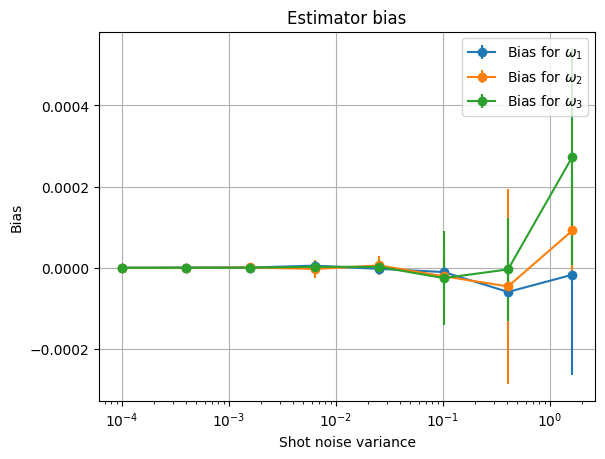

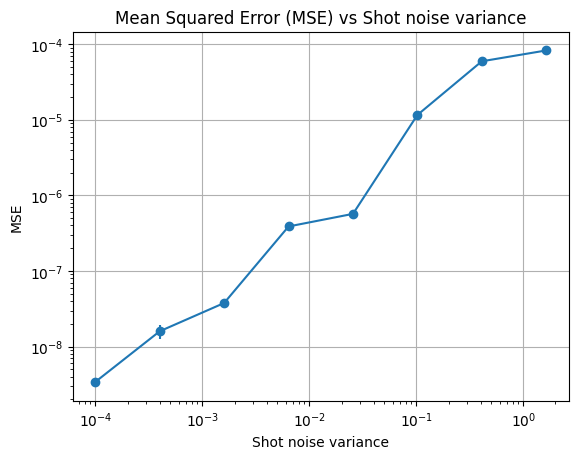

In [7]:
plt.errorbar(sn_sd_var, mean_infidelity, yerr=std_infidelity, marker='o')
plt.semilogy()
plt.semilogx()
plt.xlabel("Shot noise variance")
plt.ylabel("Infidelity")
plt.title("Infidelity between inverse of Fisher information and covariance matrix")
plt.grid()
plt.show()

plt.errorbar(sn_sd_var, np.abs([x[0] for x in mean_CRB_diff_eig]), yerr=[x[0] for x in std_CRB_diff_eig], marker = 'o', label = "Eigenvalue 1")
plt.errorbar(sn_sd_var, np.abs([x[1] for x in mean_CRB_diff_eig]), yerr=[x[1] for x in std_CRB_diff_eig], marker = 'o', label = "Eigenvalue 2")
plt.errorbar(sn_sd_var, np.abs([x[2] for x in mean_CRB_diff_eig]), yerr=[x[2] for x in std_CRB_diff_eig], marker = 'o', label = "Eigenvalue 3")
plt.legend()
plt.semilogy()
plt.semilogx()
plt.xlabel("Shot noise variance")
plt.ylabel("Eigenvalues")
plt.title("Eigenvalues of covariance matrix minus inverse of Fisher information matrix")
plt.grid()
plt.show()

plt.errorbar(sn_sd_var, mean_inv_fisher_trace, yerr=std_inv_fisher_trace, marker='o')
plt.semilogy()
plt.semilogx()
plt.xlabel("Shot noise variance")
plt.ylabel("Trace")
plt.title("Trace of inverse of Fisher information matrix")
plt.grid()
plt.show()

plt.errorbar(sn_sd_var, mean_log_det_fisher, yerr=std_log_det_fisher, marker='o')
plt.semilogy()
plt.semilogx()
plt.xlabel("Shot noise variance")
plt.ylabel("Log Determinant")
plt.title("Log of determinant of Fisher information matrix")
plt.grid()
plt.show()

for i in range(mean_bias.shape[1]):
    plt.errorbar(sn_sd_var, mean_bias[:,i], yerr = std_bias[:,i], label = f"Bias for $\omega_{i+1}$", marker = 'o')
plt.semilogx()
plt.xlabel("Shot noise variance")
plt.ylabel("Bias")
plt.title("Estimator bias")
plt.legend()
plt.grid()
plt.show()

plt.errorbar(sn_sd_var, mean_mse, yerr=std_mse, marker = 'o')
plt.xlabel("Shot noise variance")
plt.ylabel("MSE")
plt.semilogy()
plt.semilogx()
plt.title("Mean Squared Error (MSE) vs Shot noise variance")
plt.grid()
plt.show()

In [9]:
np.polyfit(sn_sd_var, mean_mse, deg = 1, full=True)
print(np.sqrt(sn_sd_var))

[0.01 0.02 0.04 0.08 0.16 0.32 0.64 1.28]


Data trotter least squares 6 ($\beta$ = 10)

In [40]:
data_6_ls = load_npy('C:/Users/alexg/python_scripts/corrected_FI_code/trotter_least_squares/data_trotter_least_squares_0.01/data_trotter_6_least_squares')
print(len(data_6_ls))
print("Runtime: ", np.max(np.sum([data_6_ls[11+i*14] for i in range(20)], axis = 1)/3600), "hours")

280
Runtime:  2.0021000962787205 hours


In [55]:
infidelity = [data_6_ls[8+i*14] for i in range(20)]
inv_fisher_trace = [data_6_ls[5+i*14] for i in range(20)]
mse = [np.sum(data_6_ls[10+i*14], axis = 1) for i in range(20)]
log_det_fisher = [np.log(np.linalg.det(data_6_ls[4+i*14])) for i in range(20)]
bias = [data_6_ls[i*14] for i in range(20)]
CRB_diff_eig = [data_6_ls[3+i*14] for i in range(20)]
sn_sd_var = data_6_ls[12]**2

mean_infidelity = np.mean(infidelity, axis=0)
std_infidelity = np.std(infidelity, axis=0)
mean_inv_fisher_trace = np.mean(inv_fisher_trace, axis=0)
std_inv_fisher_trace = np.std(inv_fisher_trace, axis=0)
mean_mse = np.mean(mse, axis=0)
std_mse = np.std(mse, axis=0)
mean_log_det_fisher = np.mean(log_det_fisher, axis=0)
std_log_det_fisher = np.std(log_det_fisher, axis=0)
mean_bias = np.mean(bias, axis=0)
std_bias = np.std(bias, axis=0)
mean_CRB_diff_eig = np.mean(CRB_diff_eig, axis=0)
std_CRB_diff_eig = np.std(CRB_diff_eig, axis=0)


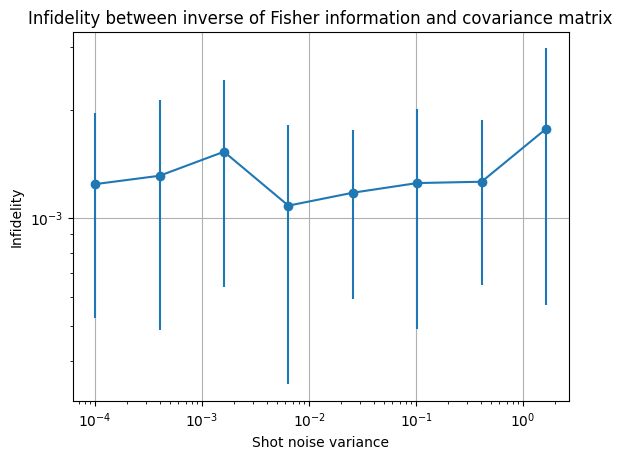

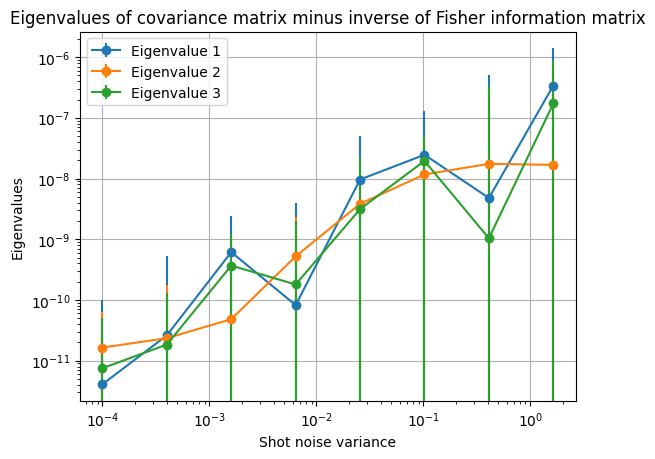

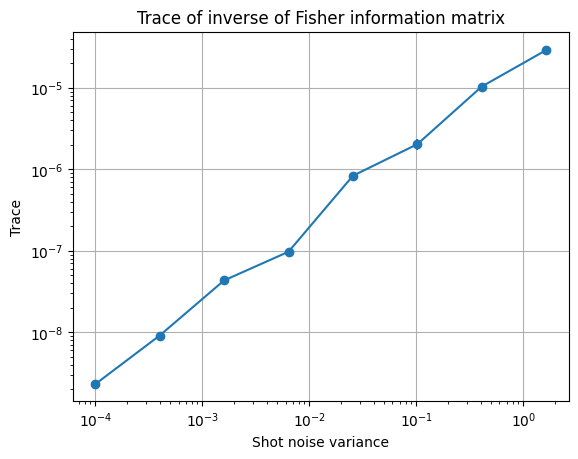

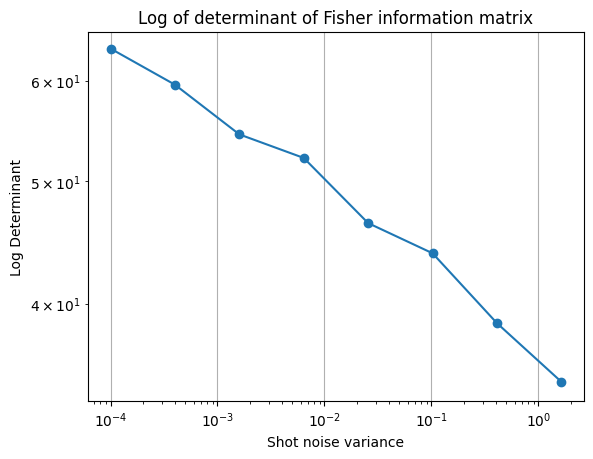

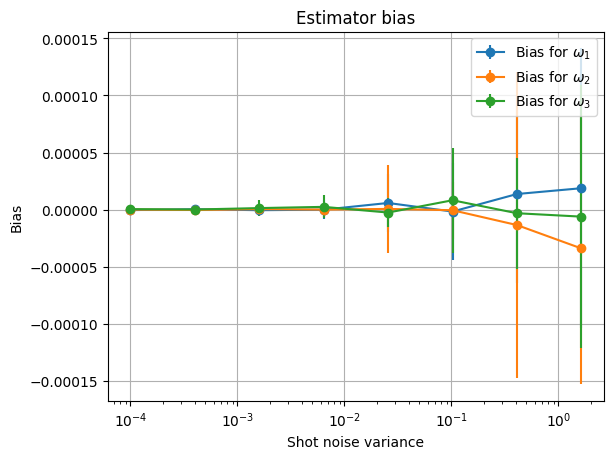

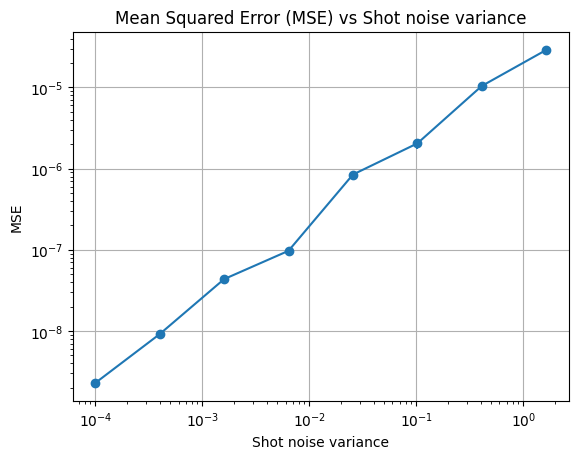

In [43]:
plt.errorbar(sn_sd_var, mean_infidelity, yerr=std_infidelity, marker='o')
plt.semilogy()
plt.semilogx()
plt.xlabel("Shot noise variance")
plt.ylabel("Infidelity")
plt.title("Infidelity between inverse of Fisher information and covariance matrix")
plt.grid()
plt.show()

plt.errorbar(sn_sd_var, np.abs([x[0] for x in mean_CRB_diff_eig]), yerr=[x[0] for x in std_CRB_diff_eig], marker = 'o', label = "Eigenvalue 1")
plt.errorbar(sn_sd_var, np.abs([x[1] for x in mean_CRB_diff_eig]), yerr=[x[1] for x in std_CRB_diff_eig], marker = 'o', label = "Eigenvalue 2")
plt.errorbar(sn_sd_var, np.abs([x[2] for x in mean_CRB_diff_eig]), yerr=[x[2] for x in std_CRB_diff_eig], marker = 'o', label = "Eigenvalue 3")
plt.legend()
plt.semilogy()
plt.semilogx()
plt.xlabel("Shot noise variance")
plt.ylabel("Eigenvalues")
plt.title("Eigenvalues of covariance matrix minus inverse of Fisher information matrix")
plt.grid()
plt.show()

plt.errorbar(sn_sd_var, mean_inv_fisher_trace, yerr=std_inv_fisher_trace, marker='o')
plt.semilogy()
plt.semilogx()
plt.xlabel("Shot noise variance")
plt.ylabel("Trace")
plt.title("Trace of inverse of Fisher information matrix")
plt.grid()
plt.show()

plt.errorbar(sn_sd_var, mean_log_det_fisher, yerr=std_log_det_fisher, marker='o')
plt.semilogy()
plt.semilogx()
plt.xlabel("Shot noise variance")
plt.ylabel("Log Determinant")
plt.title("Log of determinant of Fisher information matrix")
plt.grid()
plt.show()

for i in range(mean_bias.shape[1]):
    plt.errorbar(sn_sd_var, mean_bias[:,i], yerr = std_bias[:,i], label = f"Bias for $\omega_{i+1}$", marker = 'o')
plt.semilogx()
plt.xlabel("Shot noise variance")
plt.ylabel("Bias")
plt.title("Estimator bias")
plt.legend()
plt.grid()
plt.show()

plt.errorbar(sn_sd_var, mean_mse, yerr=std_mse, marker = 'o')
plt.xlabel("Shot noise variance")
plt.ylabel("MSE")
plt.semilogy()
plt.semilogx()
plt.title("Mean Squared Error (MSE) vs Shot noise variance")
plt.grid()
plt.show()

In [57]:
np.polyfit(sn_sd_var, mean_mse, deg = 1, full=True)

(array([1.77860173e-05, 4.41844455e-07]),
 array([8.50645193e-12]),
 2,
 array([1.2068258 , 0.73727302]),
 1.7763568394002505e-15)

Data trotter least squares 7 (Prepare SCS along z and y with 7000 time steps)

In [19]:
data_7_ls = load_npy('C:/Users/alexg/python_scripts/corrected_FI_code/trotter_least_squares/data_trotter_least_squares_0.01/data_trotter_7_least_squares')
print(len(data_7_ls))
print("Runtime: ", np.max(np.sum([data_7_ls[11+i*13] for i in range(20)], axis = 1)/3600), "hours")

260
Runtime:  0.4526399858792623 hours


In [44]:
infidelity = [data_7_ls[8+i*13] for i in range(20)]
inv_fisher_trace = [data_7_ls[5+i*13] for i in range(20)]
mse = [np.sum(data_7_ls[10+i*13], axis = 1) for i in range(20)]
log_det_fisher = [np.log(np.linalg.det(data_7_ls[4+i*13])) for i in range(20)]
bias = [data_7_ls[i*13] for i in range(20)]
CRB_diff_eig = [data_7_ls[3+i*13] for i in range(20)]

mean_infidelity = np.mean(infidelity, axis=0)
std_infidelity = np.std(infidelity, axis=0)
mean_inv_fisher_trace = np.mean(inv_fisher_trace, axis=0)
std_inv_fisher_trace = np.std(inv_fisher_trace, axis=0)
mean_mse = np.mean(mse, axis=0)
std_mse = np.std(mse, axis=0)
mean_log_det_fisher = np.mean(log_det_fisher, axis=0)
std_log_det_fisher = np.std(log_det_fisher, axis=0)
mean_bias = np.mean(bias, axis=0)
std_bias = np.std(bias, axis=0)
mean_CRB_diff_eig = np.mean(CRB_diff_eig, axis=0)
std_CRB_diff_eig = np.std(CRB_diff_eig, axis=0)

print("Mean infidelity: ", mean_infidelity)
print("Standard deviation of infidelity: ", std_infidelity)
print("Mean trace of inverse of Fisher information: ", mean_inv_fisher_trace)
print("Standard deviation of trace of inverse of Fisher information: ", std_inv_fisher_trace)
print("Mean MSE: ", mean_mse)
print("Standard deviation of MSE: ", std_mse)
print("Mean log determinant of Fisher information: ", mean_log_det_fisher)
print("Standard deviation of log determinant of Fisher information: ", std_log_det_fisher)
print("Mean bias: ", mean_bias)
print("Standard deviation of bias: ", std_bias)
print("Mean eigenvalues of covariance matrix minus inverse of Fisher information matrix: ", mean_CRB_diff_eig)
print("Standard deviation of eigenvalues of covariance matrix minus inverse of Fisher information matrix: ", std_CRB_diff_eig)

Mean infidelity:  [0.00699699]
Standard deviation of infidelity:  [0.00299932]
Mean trace of inverse of Fisher information:  [15.23868512]
Standard deviation of trace of inverse of Fisher information:  [64.49484046]
Mean MSE:  [0.04601298]
Standard deviation of MSE:  [0.01813642]
Mean log determinant of Fisher information:  [26.83669515]
Standard deviation of log determinant of Fisher information:  [5.0395923]
Mean bias:  [[ 0.00017772 -0.0135232  -0.00589998]]
Standard deviation of bias:  [[0.00124488 0.0124634  0.04373806]]
Mean eigenvalues of covariance matrix minus inverse of Fisher information matrix:  [[-1.51919970e+01  4.06991862e-06 -2.96685812e-03]]
Standard deviation of eigenvalues of covariance matrix minus inverse of Fisher information matrix:  [[6.44889563e+01 5.18178651e-06 5.47031001e-03]]


In [30]:
inv_fisher_trace

[array([0.01131259]),
 array([0.04391264]),
 array([0.01702829]),
 array([0.35652651]),
 array([0.00718474]),
 array([0.09215075]),
 array([1.2842125]),
 array([0.00378923]),
 array([0.00959426]),
 array([0.00397971]),
 array([0.2052093]),
 array([0.00238201]),
 array([0.05925324]),
 array([4.88556345]),
 array([296.32521426]),
 array([1.29678067]),
 array([0.00126166]),
 array([0.01358098]),
 array([0.15256019]),
 array([0.00220544])]

In [45]:
mse

[array([0.03700504]),
 array([0.06300759]),
 array([0.05739558]),
 array([0.07762484]),
 array([0.03948972]),
 array([0.0351687]),
 array([0.0539509]),
 array([0.04224234]),
 array([0.05423606]),
 array([0.05695142]),
 array([0.05946578]),
 array([0.02188833]),
 array([0.05579967]),
 array([0.05887164]),
 array([0.05623497]),
 array([0.03005637]),
 array([0.00455413]),
 array([0.03502512]),
 array([0.06686332]),
 array([0.01442811])]

Data trotter least squares 8 (Prepare SCS along z and y with 95 time steps)

In [14]:
data_8_ls = load_npy('C:/Users/alexg/python_scripts/corrected_FI_code/trotter_least_squares/data_trotter_least_squares_0.01/data_trotter_8_least_squares')
print(len(data_8_ls))
print("Runtime: ", np.max(np.sum([data_8_ls[11+i*13] for i in range(20)], axis = 1)/3600), "hours")

260
Runtime:  0.014315503570768568 hours


In [15]:
infidelity = [data_8_ls[8+i*13] for i in range(20)]
inv_fisher_trace = [data_8_ls[5+i*13] for i in range(20)]
mse = [np.sum(data_8_ls[10+i*13], axis = 1) for i in range(20)]
outlier_indices = [i for i, x in enumerate(mse) if x >= 1]
log_det_fisher = [np.log(np.linalg.det(data_8_ls[4+i*13])) for i in range(20)]
bias = [data_8_ls[i*13] for i in range(20)]
CRB_diff_eig = [data_8_ls[3+i*13] for i in range(20)]
for i in sorted(outlier_indices, reverse=True):
    del mse[i]
    del bias[i]
    del CRB_diff_eig[i]

mean_infidelity = np.mean(infidelity, axis=0)
std_infidelity = np.std(infidelity, axis=0)
mean_inv_fisher_trace = np.mean(inv_fisher_trace, axis=0)
std_inv_fisher_trace = np.std(inv_fisher_trace, axis=0)
mean_mse = np.mean(mse, axis=0)
std_mse = np.std(mse, axis=0)
mean_log_det_fisher = np.mean(log_det_fisher, axis=0)
std_log_det_fisher = np.std(log_det_fisher, axis=0)
mean_bias = np.mean(bias, axis=0)
std_bias = np.std(bias, axis=0)
mean_CRB_diff_eig = np.mean(CRB_diff_eig, axis=0)
std_CRB_diff_eig = np.std(CRB_diff_eig, axis=0)

print("Mean infidelity: ", mean_infidelity)
print("Standard deviation of infidelity: ", std_infidelity)
print("Mean trace of inverse of Fisher information: ", mean_inv_fisher_trace)
print("Standard deviation of trace of inverse of Fisher information: ", std_inv_fisher_trace)
print("Mean MSE: ", mean_mse)
print("Standard deviation of MSE: ", std_mse)
print("Mean log determinant of Fisher information: ", mean_log_det_fisher)
print("Standard deviation of log determinant of Fisher information: ", std_log_det_fisher)
print("Mean bias: ", mean_bias)
print("Standard deviation of bias: ", std_bias)
print("Mean eigenvalues of covariance matrix minus inverse of Fisher information matrix: ", mean_CRB_diff_eig)
print("Standard deviation of eigenvalues of covariance matrix minus inverse of Fisher information matrix: ", std_CRB_diff_eig)

Mean infidelity:  [0.19986364]
Standard deviation of infidelity:  [0.39482032]
Mean trace of inverse of Fisher information:  [0.43318249]
Standard deviation of trace of inverse of Fisher information:  [1.6116551]
Mean MSE:  [0.0444825]
Standard deviation of MSE:  [0.01613546]
Mean log determinant of Fisher information:  [28.67415205]
Standard deviation of log determinant of Fisher information:  [3.62567999]
Mean bias:  [[8.07871764e-05 7.80909590e-03 6.06240044e-03]]
Standard deviation of bias:  [[0.00113582 0.01162309 0.02047621]]
Mean eigenvalues of covariance matrix minus inverse of Fisher information matrix:  [[-4.92706539e-01  1.50325015e-06 -1.65684720e-03]]
Standard deviation of eigenvalues of covariance matrix minus inverse of Fisher information matrix:  [[1.77491504e+00 5.39891149e-06 5.17212324e-03]]


In [36]:
mse

[array([0.07220844]),
 array([0.05246218]),
 array([0.06112742]),
 array([0.02002321]),
 array([34986.6877531]),
 array([5951568.70771888]),
 array([0.04269692]),
 array([0.04823323]),
 array([0.04035007]),
 array([0.01405018]),
 array([0.03651818]),
 array([0.03239077]),
 array([0.03733548]),
 array([0.06706632]),
 array([1959722.9206158]),
 array([0.05930479]),
 array([698869.38381733]),
 array([0.04620277]),
 array([0.05633524]),
 array([0.02541473])]

In [50]:
CRB_diff_eig

[array([[ 2.28574228e-02, -3.99494028e-06, -4.07225516e-04]]),
 array([[ 2.53368626e-02, -2.73098593e-06, -1.54325689e-04]]),
 array([[ 2.29771528e-02, -1.70504531e-07, -2.94598750e-04]]),
 array([[1.44865861e-02, 1.00374631e-06, 6.44437515e-05]]),
 array([[3.49168225e+04, 6.90482850e-06, 3.14943899e-02]]),
 array([[5.93030710e+06, 1.84989887e-06, 1.83532566e-02]]),
 array([[3.43134119e-02, 3.18656814e-06, 4.20315243e-05]]),
 array([[ 4.15296134e-02, -8.96423882e-07,  9.50330392e-05]]),
 array([[ 5.86540583e-03, -8.43968825e-06, -2.93390671e-04]]),
 array([[ 1.01896733e-02, -3.91019043e-07,  5.43129464e-05]]),
 array([[3.01684293e-02, 1.76356552e-06, 1.26720372e-04]]),
 array([[2.57708737e-02, 2.47926925e-06, 1.03888428e-04]]),
 array([[ 2.17570077e-02, -1.26218011e-06, -5.07090123e-05]]),
 array([[-7.31467248e+00,  1.34252267e-05, -2.13648811e-02]]),
 array([[ 1.95391145e+06,  1.14583564e-08, -3.28836364e-04]]),
 array([[ 8.36725575e-03,  5.94685382e-06, -6.77402180e-04]]),
 array([[ 

In [ ]:
stdev = [data_8_ls[12+i*13] for i in range(20)]
rel_error = stdev[0][0]/np.array([ 0.00249883, -0.00520433, -0.00906749 ])
print("Relative error in B_x: ", rel_error[0])
print("Relative error in B_y: ", rel_error[1])
print("Relative error in B_z: ", rel_error[2])

Relative error in B_x:  0.0009941821837213575
Relative error in B_y:  -0.017598967633104798
Relative error in B_z:  -7.852573473714782


In [10]:
sigma_x_paper = np.sqrt(1.6e-15)
sigma_y_paper = np.sqrt(0.42e-15)
sigma_z_paper = np.sqrt(0.24e-15)
B_x_paper = 910e-9
B_y_paper = 285e-9
B_z_paper = 540e-9
print("Relative error in B_x in paper: ", sigma_x_paper/B_x_paper)
print("Relative error in B_y in paper: ", sigma_y_paper/B_y_paper)
print("Relative error in B_z in paper: ", sigma_z_paper/B_z_paper)

Relative error in B_x in paper:  0.04395604395604396
Relative error in B_y in paper:  0.07190842642778665
Relative error in B_z in paper:  0.02868876552746235


Data least squares 9 (No control)

In [28]:
data_9_ls = load_npy('C:/Users/alexg/python_scripts/corrected_FI_code/trotter_least_squares/data_trotter_least_squares_0.01/data_trotter_9_least_squares')
print(len(data_9_ls))
print("Runtime: ", np.max(np.sum([data_9_ls[9+i*12] for i in range(19)], axis = 1)/3600), "hours")

228
Runtime:  1.3415387241045633 hours


In [29]:
infidelity = [data_9_ls[6+i*12] for i in range(19)]
inv_fisher_trace = [data_9_ls[5+i*12] for i in range(19)]
mse = [np.sum(data_9_ls[8+i*12], axis = 1) for i in range(19)]
log_det_fisher = [np.log(np.linalg.det(data_9_ls[4+i*12])) for i in range(19)]
bias = [data_9_ls[i*12] for i in range(19)]
CRB_diff_eig = [data_9_ls[3+i*12] for i in range(19)]
t_steps = data_9_ls[11]

mean_infidelity = np.mean(infidelity, axis=0)
std_infidelity = np.std(infidelity, axis=0)
mean_inv_fisher_trace = np.mean(inv_fisher_trace, axis=0)
std_inv_fisher_trace = np.std(inv_fisher_trace, axis=0)
mean_mse = np.mean(mse, axis=0)
std_mse = np.std(mse, axis=0)
mean_log_det_fisher = np.mean(log_det_fisher, axis=0)
std_log_det_fisher = np.std(log_det_fisher, axis=0)
mean_bias = np.mean(bias, axis=0)
std_bias = np.std(bias, axis=0)
mean_CRB_diff_eig = np.mean(CRB_diff_eig, axis=0)
std_CRB_diff_eig = np.std(CRB_diff_eig, axis=0)


In [53]:
mse

[array([9.76451106e+09, 7.34138171e+12, 1.60928267e+14, 5.33911601e-05,
        7.50836425e-04, 7.47907783e-04, 7.60926545e-04, 7.49013458e-04,
        7.48301570e-04, 7.55326728e-04]),
 array([1.14022981e+10, 5.24720123e+09, 2.43756073e+13, 2.04955889e-03,
        9.16767700e-04, 9.21160540e-04, 9.31073205e-04, 9.29293573e-04,
        1.44289175e-03, 8.95911642e-04]),
 array([1.10137392e+11, 6.59536971e+09, 5.12055516e+12, 3.84841773e-05,
        2.73845287e-03, 2.75858508e-03, 2.71368793e-03, 2.70844958e-03,
        2.70887072e-03, 2.73433657e-03]),
 array([5.20423460e+12, 1.32868113e+10, 5.53675193e+11, 4.53820878e-04,
        3.40097202e-04, 2.49763417e-04, 4.32790828e-04, 1.45378176e-04,
        3.64399408e-04, 1.57222806e-04]),
 array([1.67762016e+13, 2.12224616e+09, 1.93316176e+09, 1.34863791e-04,
        7.89684314e-04, 8.07824061e-04, 7.93920457e-04, 8.29063881e-04,
        8.18554182e-04, 8.75076421e-04]),
 array([3.68683120e+10, 7.63163446e+11, 7.30646848e+13, 1.03394435e-03

In [30]:
inv_fisher_trace

[array([4.05358210e-05, 5.77812902e-05, 4.94911241e-05, 5.15341375e-05,
        5.37726382e-05, 5.30328568e-05, 5.32632404e-05, 5.33709616e-05,
        5.34785314e-05, 5.34445192e-05]),
 array([8.56144878e-05, 1.19422702e-04, 1.01305120e-04, 1.05163473e-04,
        1.09598435e-04, 1.08019375e-04, 1.08459972e-04, 1.08666116e-04,
        1.08879382e-04, 1.08806930e-04]),
 array([3.32676631e-05, 4.58683588e-05, 3.87394375e-05, 4.01461069e-05,
        4.18071209e-05, 4.11923570e-05, 4.13540777e-05, 4.14297686e-05,
        4.15096624e-05, 4.14814812e-05]),
 array([8.92224773e-05, 1.27653355e-04, 1.09420667e-04, 1.13997047e-04,
        1.18983138e-04, 1.17351703e-04, 1.17867232e-04, 1.18108268e-04,
        1.18347879e-04, 1.18272855e-04]),
 array([8.06771592e-05, 1.13241701e-04, 9.60025691e-05, 9.97479198e-05,
        1.04024243e-04, 1.02519491e-04, 1.02947057e-04, 1.03147103e-04,
        1.03352803e-04, 1.03283752e-04]),
 array([0.00010702, 0.00015267, 0.00013057, 0.00013598, 0.00014192,
  

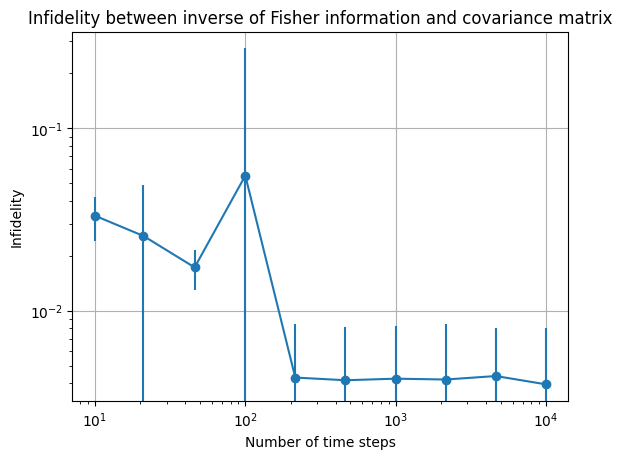

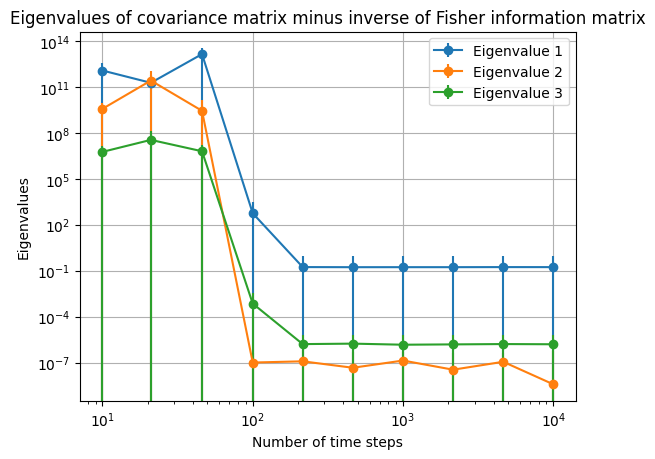

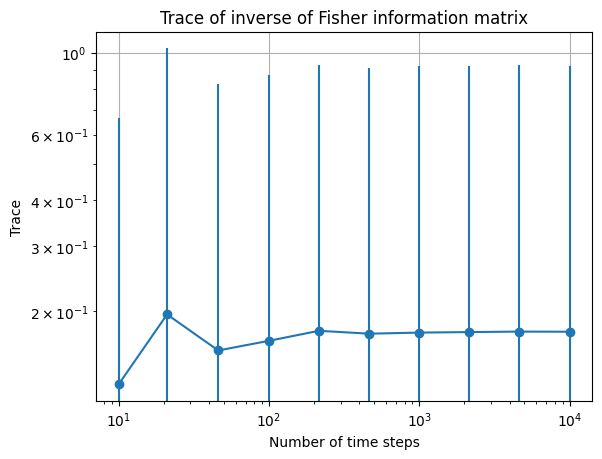

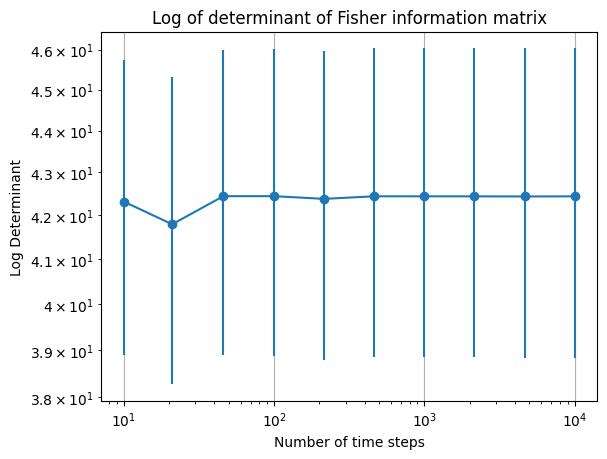

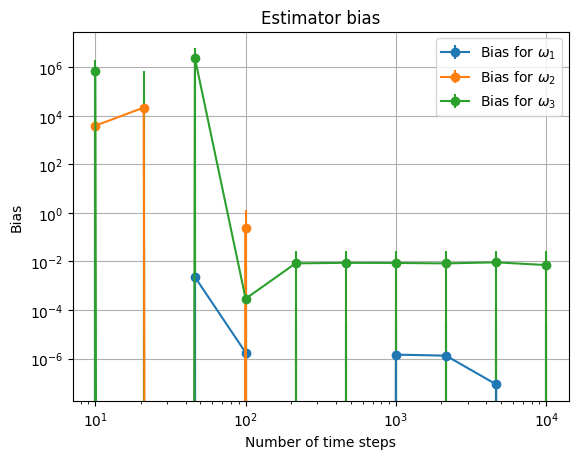

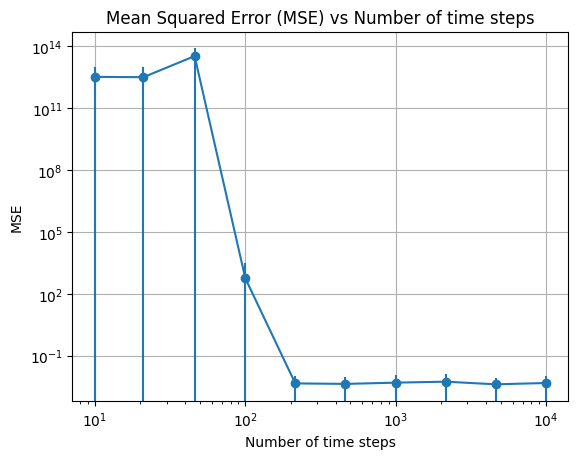

In [15]:
plt.errorbar(t_steps, mean_infidelity, yerr=std_infidelity, marker='o')
plt.semilogy()
plt.semilogx()
plt.xlabel("Number of time steps")
plt.ylabel("Infidelity")
plt.title("Infidelity between inverse of Fisher information and covariance matrix")
plt.grid()
plt.show()

plt.errorbar(t_steps, np.abs([x[0] for x in mean_CRB_diff_eig]), yerr=[x[0] for x in std_CRB_diff_eig], marker = 'o', label = "Eigenvalue 1")
plt.errorbar(t_steps, np.abs([x[1] for x in mean_CRB_diff_eig]), yerr=[x[1] for x in std_CRB_diff_eig], marker = 'o', label = "Eigenvalue 2")
plt.errorbar(t_steps, np.abs([x[2] for x in mean_CRB_diff_eig]), yerr=[x[2] for x in std_CRB_diff_eig], marker = 'o', label = "Eigenvalue 3")
plt.legend()
plt.semilogy()
plt.semilogx()
plt.xlabel("Number of time steps")
plt.ylabel("Eigenvalues")
plt.title("Eigenvalues of covariance matrix minus inverse of Fisher information matrix")
plt.grid()
plt.show()

plt.errorbar(t_steps, mean_inv_fisher_trace, yerr=std_inv_fisher_trace, marker='o')
plt.semilogy()
plt.semilogx()
plt.xlabel("Number of time steps")
plt.ylabel("Trace")
plt.title("Trace of inverse of Fisher information matrix")
plt.grid()
plt.show()

plt.errorbar(t_steps, mean_log_det_fisher, yerr=std_log_det_fisher, marker='o')
plt.semilogy()
plt.semilogx()
plt.xlabel("Number of time steps")
plt.ylabel("Log Determinant")
plt.title("Log of determinant of Fisher information matrix")
plt.grid()
plt.show()

for i in range(mean_bias.shape[1]):
    plt.errorbar(t_steps, mean_bias[:,i], yerr = std_bias[:,i], label = f"Bias for $\omega_{i+1}$", marker = 'o')
plt.semilogx()
plt.semilogy()
plt.xlabel("Number of time steps")
plt.ylabel("Bias")
plt.title("Estimator bias")
plt.legend()
plt.grid()
plt.show()

plt.errorbar(t_steps, mean_mse, yerr=std_mse, marker = 'o')
plt.xlabel("Number of time steps")
plt.ylabel("MSE")
plt.semilogy()
plt.semilogx()
plt.title("Mean Squared Error (MSE) vs Number of time steps")
plt.grid()
plt.show()

Data trotter least squares 10 (Control with beta = 0)

In [22]:
data_10_ls = load_npy('C:/Users/alexg/python_scripts/corrected_FI_code/trotter_least_squares/data_trotter_least_squares_0.01/data_trotter_10_least_squares')
print(len(data_10_ls))
print("Runtime: ", np.max(np.sum([data_10_ls[10+i*12] for i in range(20)], axis = 1)/3600), "hours")

240
Runtime:  2.6550443830092747 hours


In [7]:
infidelity = [data_10_ls[6+i*12] for i in range(20)]
inv_fisher_trace = [data_10_ls[5+i*12] for i in range(20)]
mse = [np.sum(data_10_ls[9+i*12], axis = 1) for i in range(20)]
log_det_fisher = [np.log(np.linalg.det(data_10_ls[4+i*12])) for i in range(20)]
bias = [data_10_ls[i*12] for i in range(20)]
CRB_diff_eig = [data_10_ls[3+i*12] for i in range(20)]
measurement_steps = data_10_ls[8]

mean_infidelity = np.mean(infidelity, axis=0)
std_infidelity = np.std(infidelity, axis=0)
mean_inv_fisher_trace = np.mean(inv_fisher_trace, axis=0)
std_inv_fisher_trace = np.std(inv_fisher_trace, axis=0)
mean_mse = np.mean(mse, axis=0)
std_mse = np.std(mse, axis=0)
mean_log_det_fisher = np.mean(log_det_fisher, axis=0)
std_log_det_fisher = np.std(log_det_fisher, axis=0)
mean_bias = np.mean(bias, axis=0)
std_bias = np.std(bias, axis=0)
mean_CRB_diff_eig = np.mean(CRB_diff_eig, axis=0)
std_CRB_diff_eig = np.std(CRB_diff_eig, axis=0)


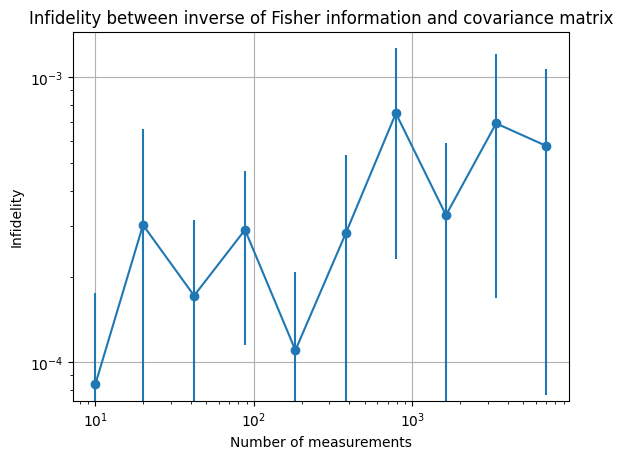

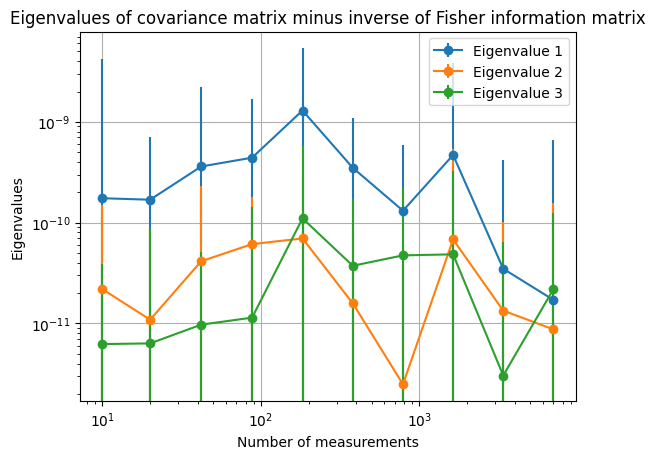

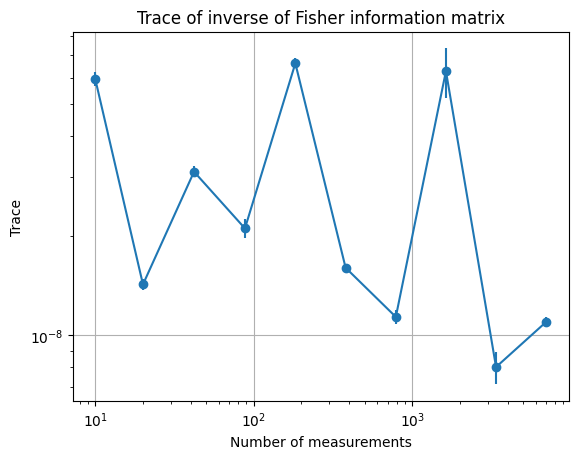

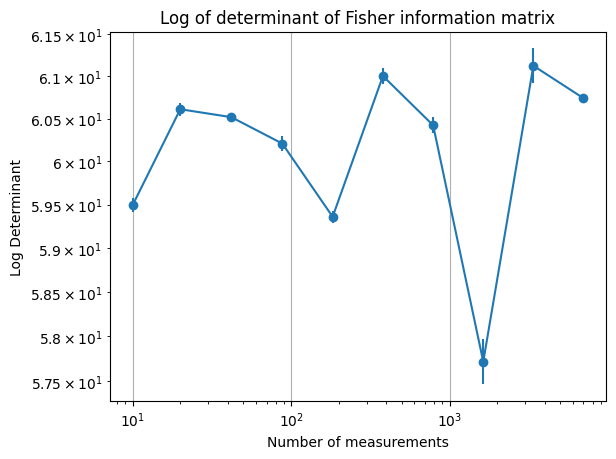

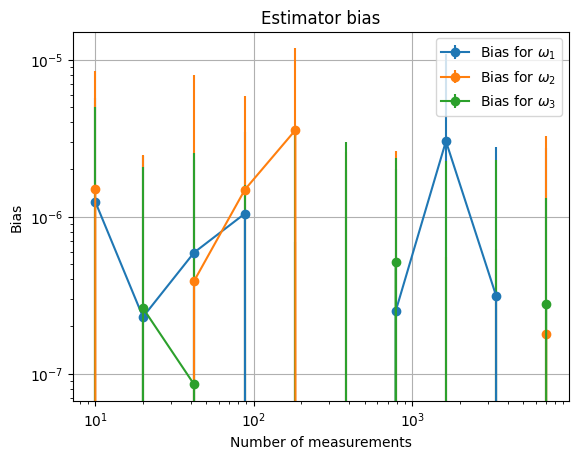

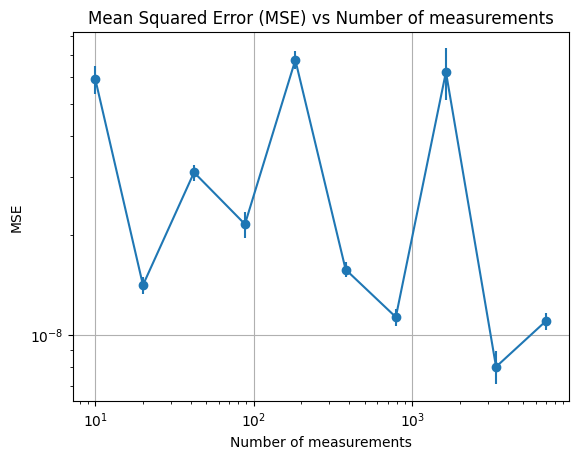

In [8]:
plt.errorbar(measurement_steps, mean_infidelity, yerr=std_infidelity, marker='o')
plt.semilogy()
plt.semilogx()
plt.xlabel("Number of measurements")
plt.ylabel("Infidelity")
plt.title("Infidelity between inverse of Fisher information and covariance matrix")
plt.grid()
plt.show()

plt.errorbar(measurement_steps, np.abs([x[0] for x in mean_CRB_diff_eig]), yerr=[x[0] for x in std_CRB_diff_eig], marker = 'o', label = "Eigenvalue 1")
plt.errorbar(measurement_steps, np.abs([x[1] for x in mean_CRB_diff_eig]), yerr=[x[1] for x in std_CRB_diff_eig], marker = 'o', label = "Eigenvalue 2")
plt.errorbar(measurement_steps, np.abs([x[2] for x in mean_CRB_diff_eig]), yerr=[x[2] for x in std_CRB_diff_eig], marker = 'o', label = "Eigenvalue 3")
plt.legend()
plt.semilogy()
plt.semilogx()
plt.xlabel("Number of measurements")
plt.ylabel("Eigenvalues")
plt.title("Eigenvalues of covariance matrix minus inverse of Fisher information matrix")
plt.grid()
plt.show()

plt.errorbar(measurement_steps, mean_inv_fisher_trace, yerr=std_inv_fisher_trace, marker='o')
plt.semilogy()
plt.semilogx()
plt.xlabel("Number of measurements")
plt.ylabel("Trace")
plt.title("Trace of inverse of Fisher information matrix")
plt.grid()
plt.show()

plt.errorbar(measurement_steps, mean_log_det_fisher, yerr=std_log_det_fisher, marker='o')
plt.semilogy()
plt.semilogx()
plt.xlabel("Number of measurements")
plt.ylabel("Log Determinant")
plt.title("Log of determinant of Fisher information matrix")
plt.grid()
plt.show()

for i in range(mean_bias.shape[1]):
    plt.errorbar(measurement_steps, mean_bias[:,i], yerr = std_bias[:,i], label = f"Bias for $\omega_{i+1}$", marker = 'o')
plt.semilogx()
plt.semilogy()
plt.xlabel("Number of measurements")
plt.ylabel("Bias")
plt.title("Estimator bias")
plt.legend()
plt.grid()
plt.show()

plt.errorbar(measurement_steps, mean_mse, yerr=std_mse, marker = 'o')
plt.xlabel("Number of measurements")
plt.ylabel("MSE")
plt.semilogy()
plt.semilogx()
plt.title("Mean Squared Error (MSE) vs Number of measurements")
plt.grid()
plt.show()

Data trotter 11 least squares (Control beta=1)

In [23]:
data_11_ls = load_npy('C:/Users/alexg/python_scripts/corrected_FI_code/trotter_least_squares/data_trotter_least_squares_0.01/data_trotter_11_least_squares')
print(len(data_11_ls))
print("Runtime: ", np.max(np.sum([data_11_ls[10+i*12] for i in range(20)], axis = 1)/3600), "hours")

240
Runtime:  1.4595368541611566 hours


In [24]:
infidelity = [data_11_ls[6+i*12] for i in range(20)]
inv_fisher_trace = [data_11_ls[5+i*12] for i in range(20)]
mse = [np.sum(data_11_ls[9+i*12], axis = 1) for i in range(20)]
log_det_fisher = [np.log(np.linalg.det(data_11_ls[4+i*12])) for i in range(20)]
bias = [data_11_ls[i*12] for i in range(20)]
CRB_diff_eig = [data_11_ls[3+i*12] for i in range(20)]
measurement_steps = data_11_ls[8]

mean_infidelity = np.mean(infidelity, axis=0)
std_infidelity = np.std(infidelity, axis=0)
mean_inv_fisher_trace = np.mean(inv_fisher_trace, axis=0)
std_inv_fisher_trace = np.std(inv_fisher_trace, axis=0)
mean_mse = np.mean(mse, axis=0)
std_mse = np.std(mse, axis=0)
mean_log_det_fisher = np.mean(log_det_fisher, axis=0)
std_log_det_fisher = np.std(log_det_fisher, axis=0)
mean_bias = np.mean(bias, axis=0)
std_bias = np.std(bias, axis=0)
mean_CRB_diff_eig = np.mean(CRB_diff_eig, axis=0)
std_CRB_diff_eig = np.std(CRB_diff_eig, axis=0)


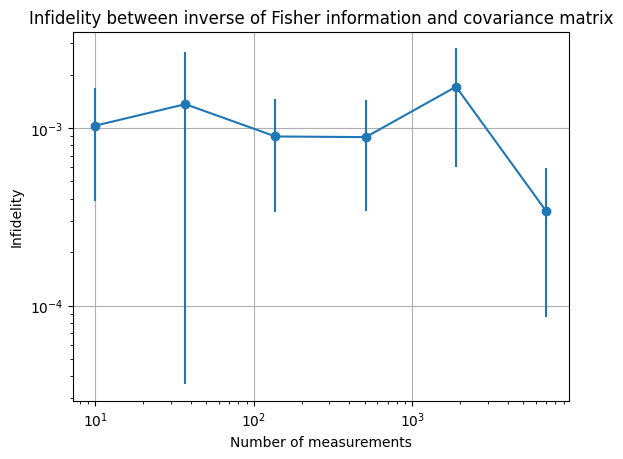

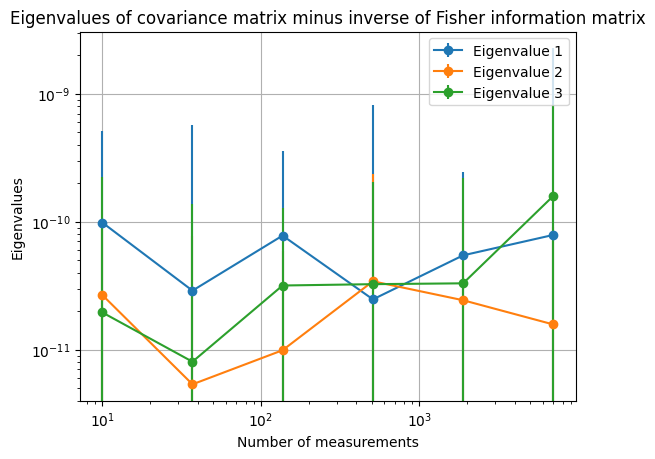

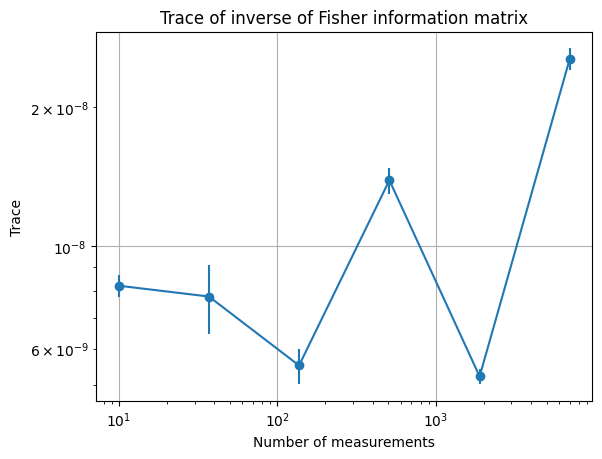

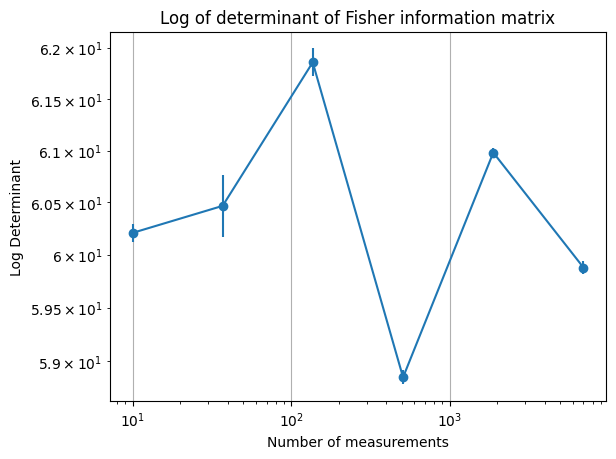

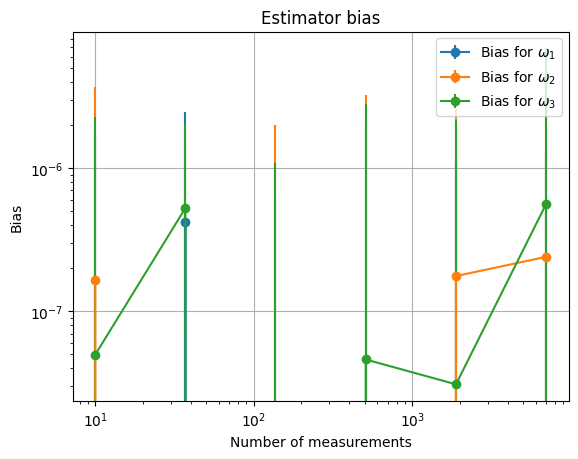

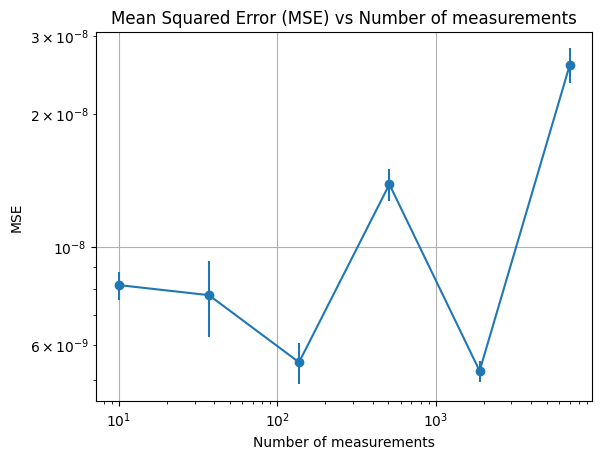

In [25]:
plt.errorbar(measurement_steps, mean_infidelity, yerr=std_infidelity, marker='o')
plt.semilogy()
plt.semilogx()
plt.xlabel("Number of measurements")
plt.ylabel("Infidelity")
plt.title("Infidelity between inverse of Fisher information and covariance matrix")
plt.grid()
plt.show()

plt.errorbar(measurement_steps, np.abs([x[0] for x in mean_CRB_diff_eig]), yerr=[x[0] for x in std_CRB_diff_eig], marker = 'o', label = "Eigenvalue 1")
plt.errorbar(measurement_steps, np.abs([x[1] for x in mean_CRB_diff_eig]), yerr=[x[1] for x in std_CRB_diff_eig], marker = 'o', label = "Eigenvalue 2")
plt.errorbar(measurement_steps, np.abs([x[2] for x in mean_CRB_diff_eig]), yerr=[x[2] for x in std_CRB_diff_eig], marker = 'o', label = "Eigenvalue 3")
plt.legend()
plt.semilogy()
plt.semilogx()
plt.xlabel("Number of measurements")
plt.ylabel("Eigenvalues")
plt.title("Eigenvalues of covariance matrix minus inverse of Fisher information matrix")
plt.grid()
plt.show()

plt.errorbar(measurement_steps, mean_inv_fisher_trace, yerr=std_inv_fisher_trace, marker='o')
plt.semilogy()
plt.semilogx()
plt.xlabel("Number of measurements")
plt.ylabel("Trace")
plt.title("Trace of inverse of Fisher information matrix")
plt.grid()
plt.show()

plt.errorbar(measurement_steps, mean_log_det_fisher, yerr=std_log_det_fisher, marker='o')
plt.semilogy()
plt.semilogx()
plt.xlabel("Number of measurements")
plt.ylabel("Log Determinant")
plt.title("Log of determinant of Fisher information matrix")
plt.grid()
plt.show()

for i in range(mean_bias.shape[1]):
    plt.errorbar(measurement_steps, mean_bias[:,i], yerr = std_bias[:,i], label = f"Bias for $\omega_{i+1}$", marker = 'o')
plt.semilogx()
plt.semilogy()
plt.xlabel("Number of measurements")
plt.ylabel("Bias")
plt.title("Estimator bias")
plt.legend()
plt.grid()
plt.show()

plt.errorbar(measurement_steps, mean_mse, yerr=std_mse, marker = 'o')
plt.xlabel("Number of measurements")
plt.ylabel("MSE")
plt.semilogy()
plt.semilogx()
plt.title("Mean Squared Error (MSE) vs Number of measurements")
plt.grid()
plt.show()

Data trotter 12 least squares (Control, beta = 1, one choice of parameter)

In [47]:
data_12_ls = load_npy('C:/Users/alexg/python_scripts/corrected_FI_code/trotter_least_squares/data_trotter_least_squares_0.01/data_trotter_12_least_squares_1')


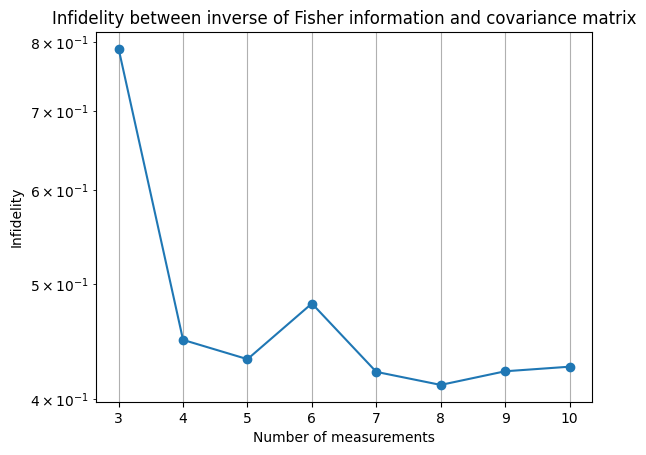

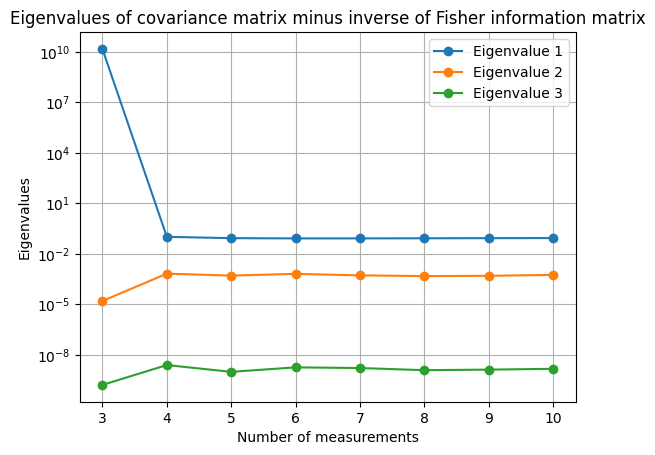

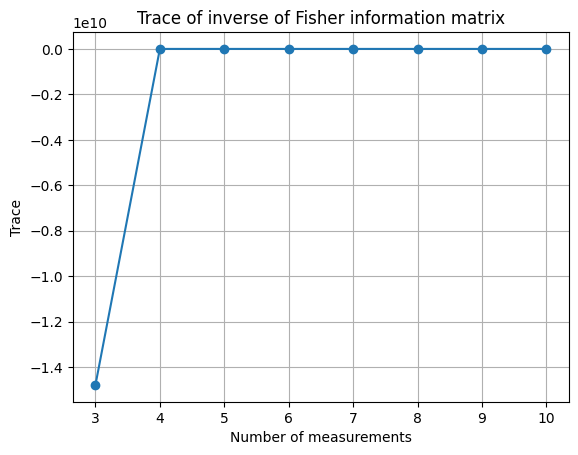

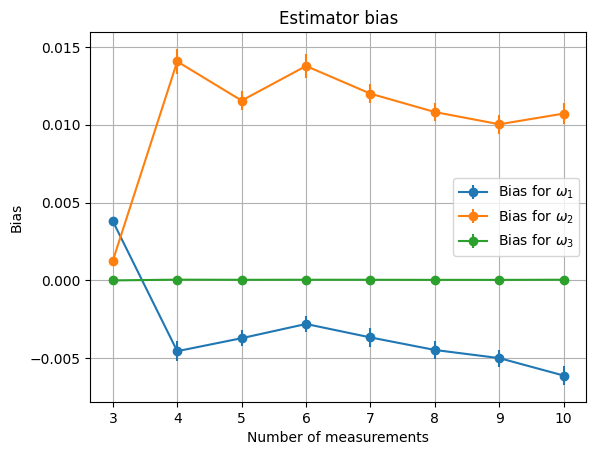

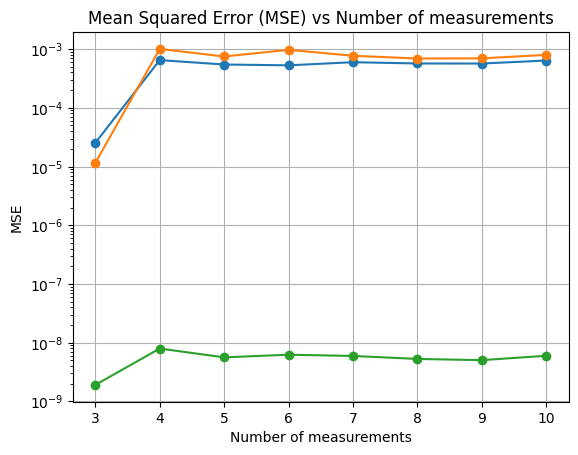

In [48]:
plt.plot(data_12_ls[8], data_12_ls[6], marker='o')
plt.semilogy()
#plt.semilogx()
plt.xlabel("Number of measurements")
plt.ylabel("Infidelity")
plt.title("Infidelity between inverse of Fisher information and covariance matrix")
plt.grid()
plt.show()

plt.plot(data_12_ls[8], np.abs([x[0] for x in data_12_ls[3]]), marker = 'o', label = "Eigenvalue 1")
plt.plot(data_12_ls[8], np.abs([x[1] for x in data_12_ls[3]]), marker = 'o', label = "Eigenvalue 2")
plt.plot(data_12_ls[8], np.abs([x[2] for x in data_12_ls[3]]), marker = 'o', label = "Eigenvalue 3")
plt.legend()
plt.semilogy()
#plt.semilogx()
plt.xlabel("Number of measurements")
plt.ylabel("Eigenvalues")
plt.title("Eigenvalues of covariance matrix minus inverse of Fisher information matrix")
plt.grid()
plt.show()

plt.plot(data_12_ls[8], data_12_ls[5], marker='o')
#plt.semilogy()
#plt.semilogx()
plt.xlabel("Number of measurements")
plt.ylabel("Trace")
plt.title("Trace of inverse of Fisher information matrix")
plt.grid()
plt.show()

for i in range(data_12_ls[0].shape[1]):
    plt.errorbar(data_12_ls[8], data_12_ls[0][:,i], yerr = data_12_ls[11][:,i], label = f"Bias for $\omega_{i+1}$", marker = 'o')
#plt.semilogx()
#plt.semilogy()
plt.xlabel("Number of measurements")
plt.ylabel("Bias")
plt.title("Estimator bias")
plt.legend()
plt.grid()
plt.show()

plt.plot(data_12_ls[8], data_12_ls[9], marker = 'o')
plt.xlabel("Number of measurements")
plt.ylabel("MSE")
plt.semilogy()
#plt.semilogx()
plt.title("Mean Squared Error (MSE) vs Number of measurements")
plt.grid()
plt.show()

Data trotter 13 least squares (No control, prepare SCS along z and y, one choice of parameter)

In [45]:
data_13_ls = load_npy('C:/Users/alexg/python_scripts/corrected_FI_code/trotter_least_squares/data_trotter_least_squares_0.01/data_trotter_13_least_squares_1')

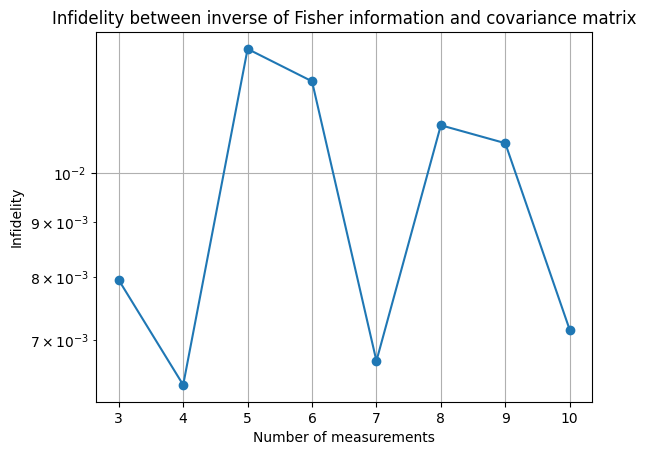

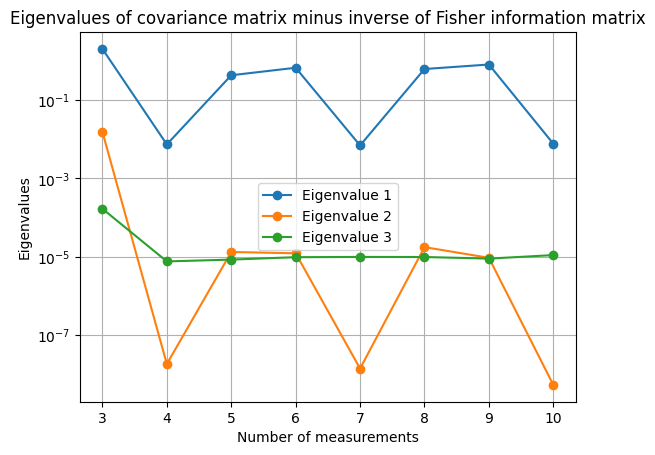

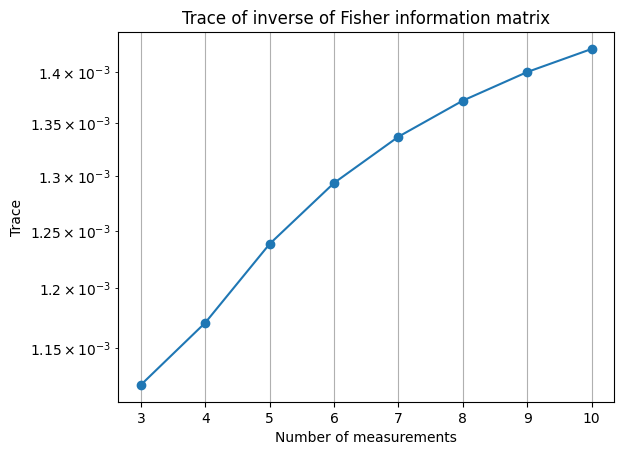

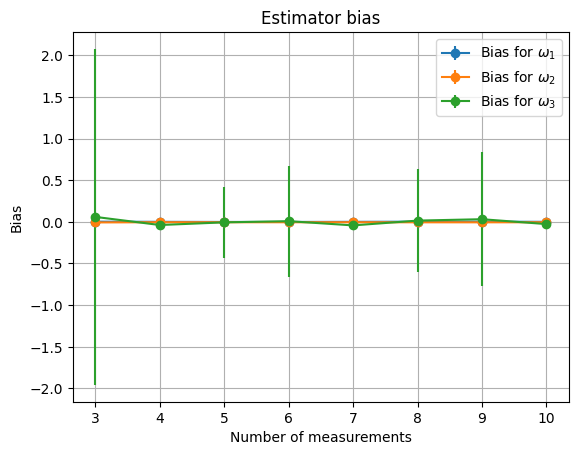

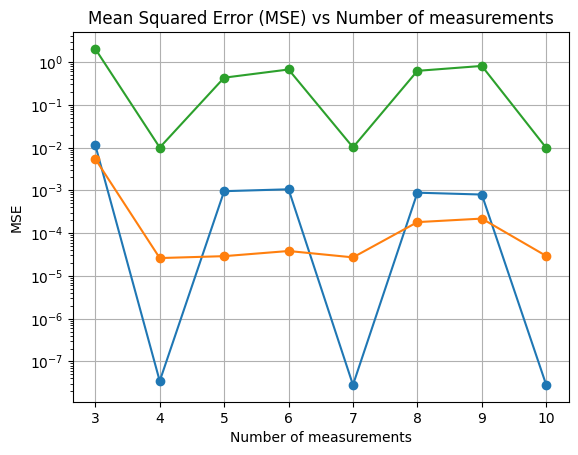

In [46]:
plt.plot(data_13_ls[8], data_13_ls[6], marker='o')
plt.semilogy()
#plt.semilogx()
plt.xlabel("Number of measurements")
plt.ylabel("Infidelity")
plt.title("Infidelity between inverse of Fisher information and covariance matrix")
plt.grid()
plt.show()

plt.plot(data_13_ls[8], np.abs([x[0] for x in data_13_ls[3]]), marker = 'o', label = "Eigenvalue 1")
plt.plot(data_13_ls[8], np.abs([x[1] for x in data_13_ls[3]]), marker = 'o', label = "Eigenvalue 2")
plt.plot(data_13_ls[8], np.abs([x[2] for x in data_13_ls[3]]), marker = 'o', label = "Eigenvalue 3")
plt.legend()
plt.semilogy()
#plt.semilogx()
plt.xlabel("Number of measurements")
plt.ylabel("Eigenvalues")
plt.title("Eigenvalues of covariance matrix minus inverse of Fisher information matrix")
plt.grid()
plt.show()

plt.plot(data_13_ls[8], data_13_ls[5], marker='o')
plt.semilogy()
#plt.semilogx()
plt.xlabel("Number of measurements")
plt.ylabel("Trace")
plt.title("Trace of inverse of Fisher information matrix")
plt.grid()
plt.show()

for i in range(data_13_ls[0].shape[1]):
    plt.errorbar(data_13_ls[8], data_13_ls[0][:,i], yerr = data_13_ls[11][:,i], label = f"Bias for $\omega_{i+1}$", marker = 'o')
#plt.semilogx()
#plt.semilogy()
plt.xlabel("Number of measurements")
plt.ylabel("Bias")
plt.title("Estimator bias")
plt.legend()
plt.grid()
plt.show()

plt.plot(data_13_ls[8], data_13_ls[9], marker = 'o')
plt.xlabel("Number of measurements")
plt.ylabel("MSE")
plt.semilogy()
#plt.semilogx()
plt.title("Mean Squared Error (MSE) vs Number of measurements")
plt.grid()
plt.show()

Data trotter least squares 15 (Same parameters and method as paper)

In [49]:
data_15_ls = load_npy('C:/Users/alexg/python_scripts/corrected_FI_code/trotter_least_squares/data_trotter_least_squares_0.01/data_trotter_15_least_squares_1')

In [54]:
data = data_15_ls

num_measurements = data[8]

print("Infidelity between inverse Fisher information and covariance matrix")
for n, val in zip(num_measurements, data[6]):
    print(f"Measurements: {n}, Infidelity: {val}")

print("\nEigenvalues of covariance matrix minus inverse Fisher information matrix")
for n, eigs in zip(num_measurements, data[3]):
    print(
        f"Measurements: {n}, "
        f"Eigenvalue 1: {abs(eigs[0])}, "
        f"Eigenvalue 2: {abs(eigs[1])}, "
        f"Eigenvalue 3: {abs(eigs[2])}"
    )

print("\nTrace of inverse Fisher information matrix")
for n, val in zip(num_measurements, data[5]):
    print(f"Measurements: {n}, Trace: {val}")

print("\nEstimator bias")
for i in range(data[0].shape[1]):
    print(f"\nBias for omega_{i+1}")
    for n, bias, err in zip(num_measurements, data[0][:, i], data[11][:, i]):
        print(f"Measurements: {n}, Bias: {bias}, Error: {err}")

print("\nMean Squared Error (MSE) vs Number of measurements")
for n, val in zip(num_measurements, data[9]):
    print(f"Measurements: {n}, MSE: {val}")


Infidelity between inverse Fisher information and covariance matrix
Measurements: 48, Infidelity: 0.34418520161747135

Eigenvalues of covariance matrix minus inverse Fisher information matrix
Measurements: 48, Eigenvalue 1: 12.928640108144196, Eigenvalue 2: 1.4882948707764634e-05, Eigenvalue 3: 0.00017699760882851083

Trace of inverse Fisher information matrix
Measurements: 48, Trace: 0.0006417975565936668

Estimator bias

Bias for omega_1
Measurements: 48, Bias: -37.72512922404739, Error: 2.253115582199567e-05

Bias for omega_2
Measurements: 48, Bias: -11.156743337202274, Error: 8.503122186852133

Bias for omega_3
Measurements: 48, Bias: -24.740987933237843, Error: 4.425975073032707

Mean Squared Error (MSE) vs Number of measurements
Measurements: 48, MSE: [1423.1853975   132.97604408  616.54245899]


Data trotter least squares 16 (control, beta = 1, same parameters as paper)

In [52]:
data_16_ls = load_npy('C:/Users/alexg/python_scripts/corrected_FI_code/trotter_least_squares/data_trotter_least_squares_0.01/data_trotter_16_least_squares_1')

In [55]:
data = data_16_ls

num_measurements = data[8]

print("Infidelity between inverse Fisher information and covariance matrix")
for n, val in zip(num_measurements, data[6]):
    print(f"Measurements: {n}, Infidelity: {val}")

print("\nEigenvalues of covariance matrix minus inverse Fisher information matrix")
for n, eigs in zip(num_measurements, data[3]):
    print(
        f"Measurements: {n}, "
        f"Eigenvalue 1: {abs(eigs[0])}, "
        f"Eigenvalue 2: {abs(eigs[1])}, "
        f"Eigenvalue 3: {abs(eigs[2])}"
    )

print("\nTrace of inverse Fisher information matrix")
for n, val in zip(num_measurements, data[5]):
    print(f"Measurements: {n}, Trace: {val}")

print("\nEstimator bias")
for i in range(data[0].shape[1]):
    print(f"\nBias for omega_{i+1}")
    for n, bias, err in zip(num_measurements, data[0][:, i], data[11][:, i]):
        print(f"Measurements: {n}, Bias: {bias}, Error: {err}")

print("\nMean Squared Error (MSE) vs Number of measurements")
for n, val in zip(num_measurements, data[9]):
    print(f"Measurements: {n}, MSE: {val}")


Infidelity between inverse Fisher information and covariance matrix
Measurements: 48, Infidelity: 0.7473774531893985

Eigenvalues of covariance matrix minus inverse Fisher information matrix
Measurements: 48, Eigenvalue 1: 3.7295085360409728e-06, Eigenvalue 2: 0.00026566592140004084, Eigenvalue 3: 0.00012704916760629794

Trace of inverse Fisher information matrix
Measurements: 48, Trace: 0.0003950629628845146

Estimator bias

Bias for omega_1
Measurements: 48, Bias: -39.07144344174857, Error: 4.07109497574597e-06

Bias for omega_2
Measurements: 48, Bias: -13.525656983656335, Error: 8.380421098815571e-07

Bias for omega_3
Measurements: 48, Bias: -22.94441132730328, Error: 1.1682453285892848e-06

Mean Squared Error (MSE) vs Number of measurements
Measurements: 48, MSE: [1526.57769669  182.94339768  526.44601232]


Data trotter least squares 17 (same parameters and method as paper)

In [56]:
data_17_ls = load_npy('C:/Users/alexg/python_scripts/corrected_FI_code/trotter_least_squares/data_trotter_least_squares_0.01/data_trotter_17_least_squares_1')

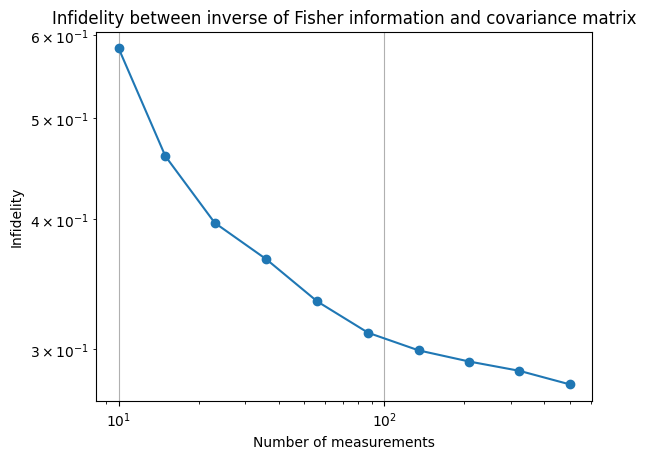

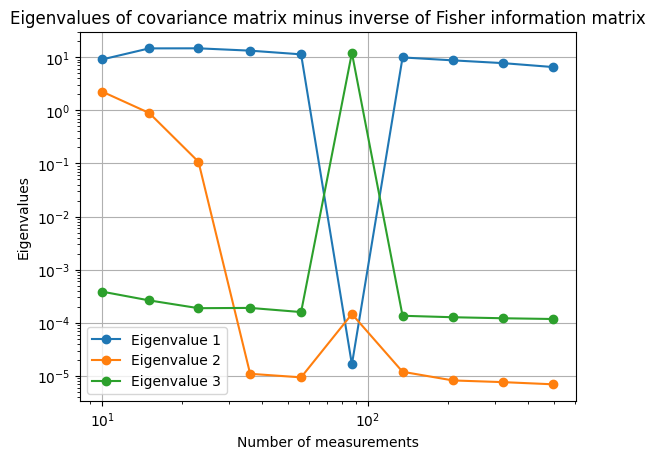

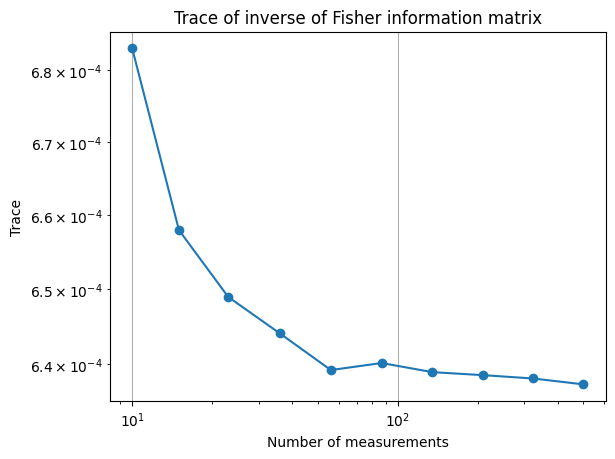

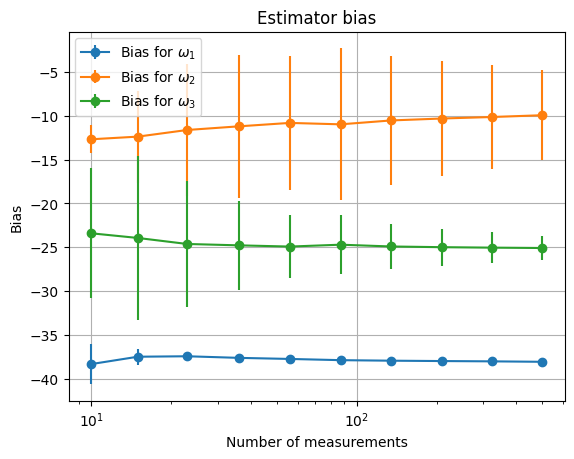

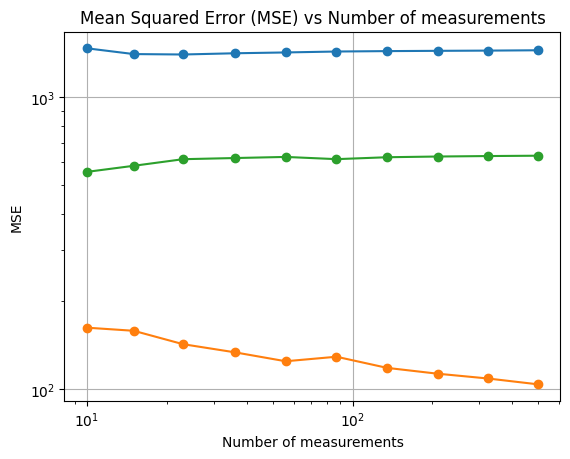

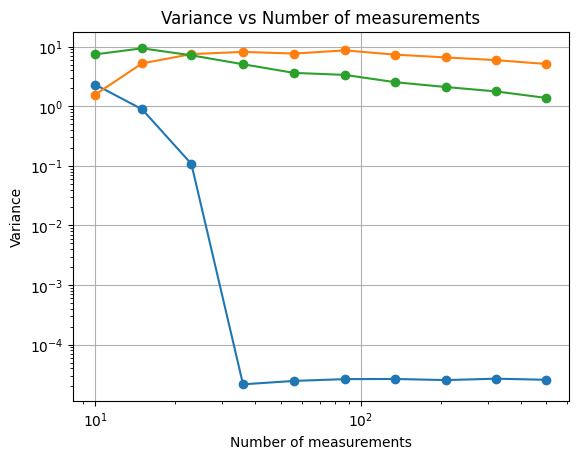

In [62]:
data = data_17_ls
plt.plot(data[8], data[6], marker='o')
plt.semilogy()
plt.semilogx()
plt.xlabel("Number of measurements")
plt.ylabel("Infidelity")
plt.title("Infidelity between inverse of Fisher information and covariance matrix")
plt.grid()
plt.show()

plt.plot(data[8], np.abs([x[0] for x in data[3]]), marker = 'o', label = "Eigenvalue 1")
plt.plot(data[8], np.abs([x[1] for x in data[3]]), marker = 'o', label = "Eigenvalue 2")
plt.plot(data[8], np.abs([x[2] for x in data[3]]), marker = 'o', label = "Eigenvalue 3")
plt.legend()
plt.semilogy()
plt.semilogx()
plt.xlabel("Number of measurements")
plt.ylabel("Eigenvalues")
plt.title("Eigenvalues of covariance matrix minus inverse of Fisher information matrix")
plt.grid()
plt.show()

plt.plot(data[8], data[5], marker='o')
plt.semilogy()
plt.semilogx()
plt.xlabel("Number of measurements")
plt.ylabel("Trace")
plt.title("Trace of inverse of Fisher information matrix")
plt.grid()
plt.show()

for i in range(data[0].shape[1]):
    plt.errorbar(data[8], data[0][:,i], yerr = data[11][:,i], label = f"Bias for $\omega_{i+1}$", marker = 'o')
plt.semilogx()
#plt.semilogy()
plt.xlabel("Number of measurements")
plt.ylabel("Bias")
plt.title("Estimator bias")
plt.legend()
plt.grid()
plt.show()

plt.plot(data[8], data[9], marker = 'o')
plt.xlabel("Number of measurements")
plt.ylabel("MSE")
plt.semilogy()
plt.semilogx()
plt.title("Mean Squared Error (MSE) vs Number of measurements")
plt.grid()
plt.show()

plt.plot(data[8], data[11], marker = 'o')
plt.xlabel("Number of measurements")
plt.ylabel("Variance")
plt.semilogy()
plt.semilogx()
plt.title("Variance vs Number of measurements")
plt.grid()
plt.show()

Data trotter least squares 18 (Control, beta = 1, same parameters as paper)

In [59]:
data_18_ls = load_npy('C:/Users/alexg/python_scripts/corrected_FI_code/trotter_least_squares/data_trotter_least_squares_0.01/data_trotter_18_least_squares_1')

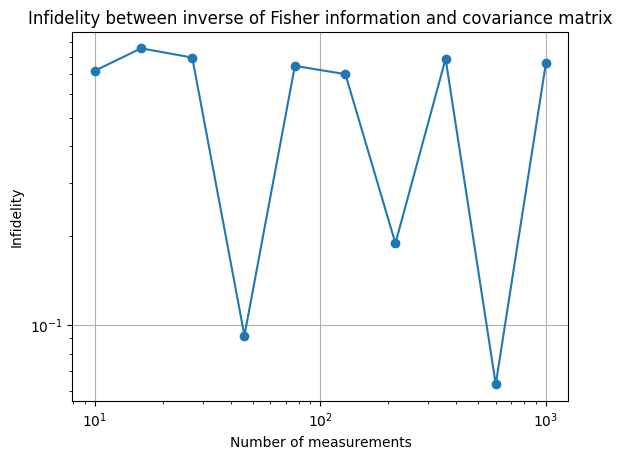

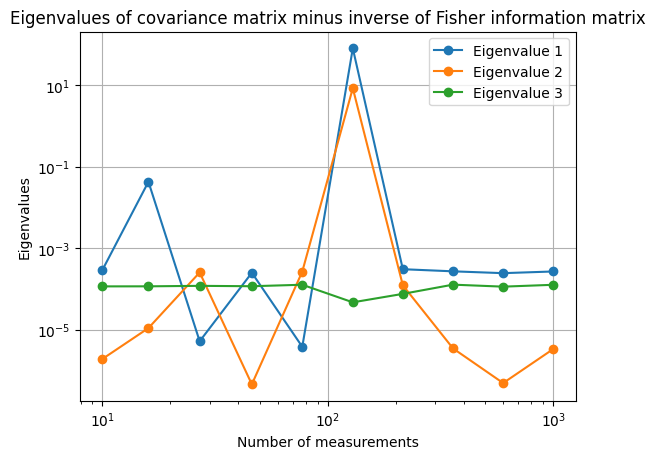

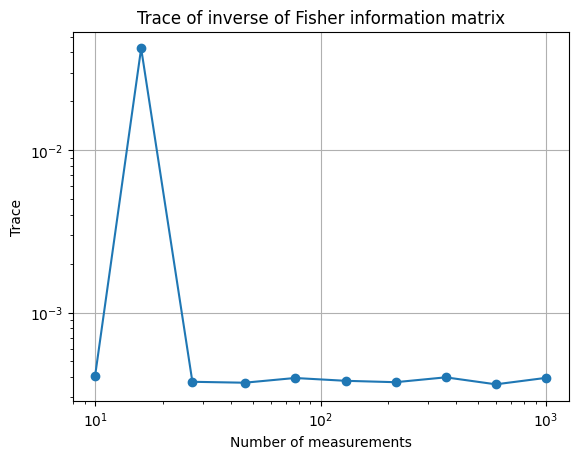

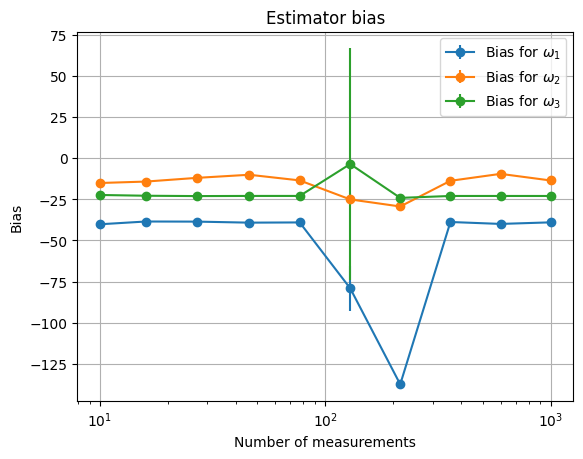

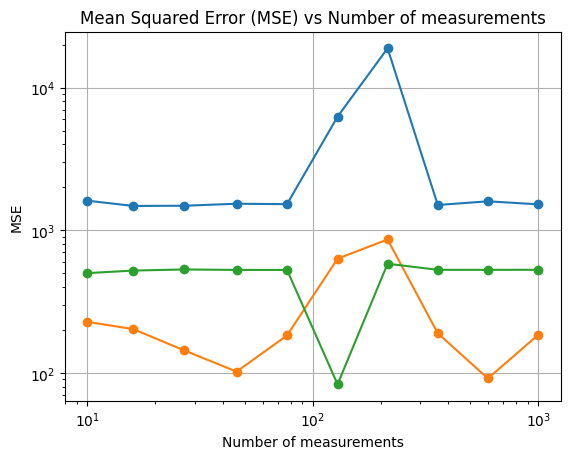

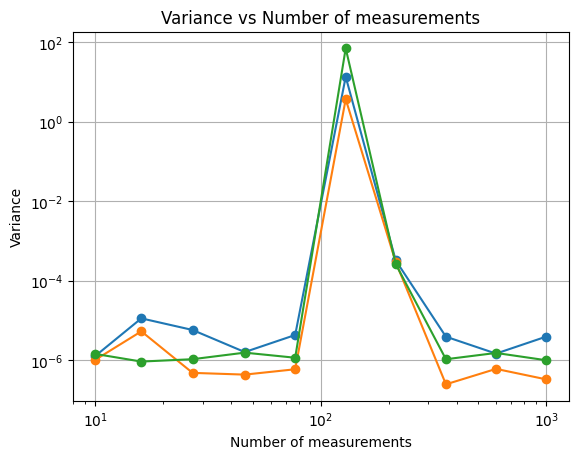

In [63]:
data = data_18_ls
plt.plot(data[8], data[6], marker='o')
plt.semilogy()
plt.semilogx()
plt.xlabel("Number of measurements")
plt.ylabel("Infidelity")
plt.title("Infidelity between inverse of Fisher information and covariance matrix")
plt.grid()
plt.show()

plt.plot(data[8], np.abs([x[0] for x in data[3]]), marker = 'o', label = "Eigenvalue 1")
plt.plot(data[8], np.abs([x[1] for x in data[3]]), marker = 'o', label = "Eigenvalue 2")
plt.plot(data[8], np.abs([x[2] for x in data[3]]), marker = 'o', label = "Eigenvalue 3")
plt.legend()
plt.semilogy()
plt.semilogx()
plt.xlabel("Number of measurements")
plt.ylabel("Eigenvalues")
plt.title("Eigenvalues of covariance matrix minus inverse of Fisher information matrix")
plt.grid()
plt.show()

plt.plot(data[8], data[5], marker='o')
plt.semilogy()
plt.semilogx()
plt.xlabel("Number of measurements")
plt.ylabel("Trace")
plt.title("Trace of inverse of Fisher information matrix")
plt.grid()
plt.show()

for i in range(data[0].shape[1]):
    plt.errorbar(data[8], data[0][:,i], yerr = data[11][:,i], label = f"Bias for $\omega_{i+1}$", marker = 'o')
plt.semilogx()
#plt.semilogy()
plt.xlabel("Number of measurements")
plt.ylabel("Bias")
plt.title("Estimator bias")
plt.legend()
plt.grid()
plt.show()

plt.plot(data[8], data[9], marker = 'o')
plt.xlabel("Number of measurements")
plt.ylabel("MSE")
plt.semilogy()
plt.semilogx()
plt.title("Mean Squared Error (MSE) vs Number of measurements")
plt.grid()
plt.show()

plt.plot(data[8], data[11], marker = 'o')
plt.xlabel("Number of measurements")
plt.ylabel("Variance")
plt.semilogy()
plt.semilogx()
plt.title("Variance vs Number of measurements")
plt.grid()
plt.show()

Data trotter least squares 19 (same parameters and method as paper with intial guess close to true parameters)

In [3]:
data_19_ls = load_npy('C:/Users/alexg/python_scripts/corrected_FI_code/trotter_least_squares/data_trotter_least_squares_0.01/data_trotter_19_least_squares_1')

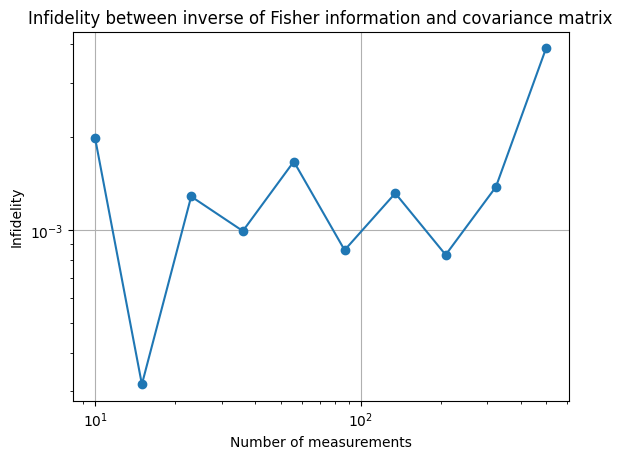

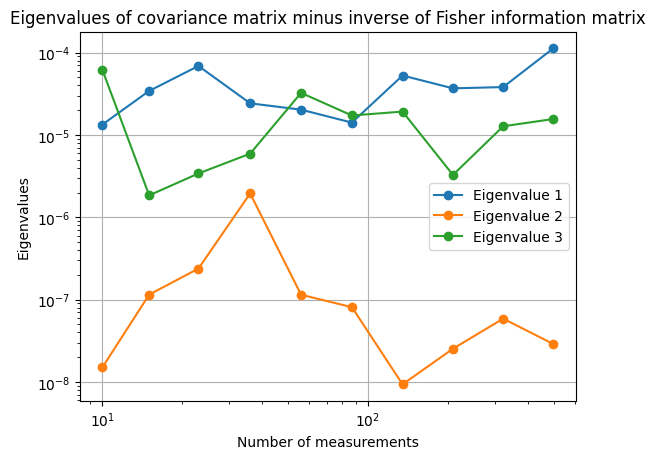

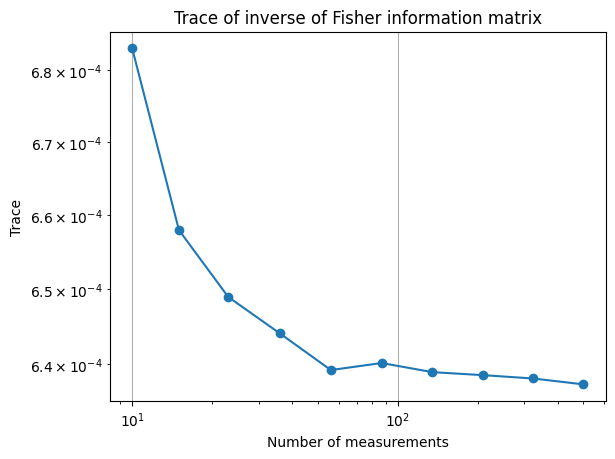

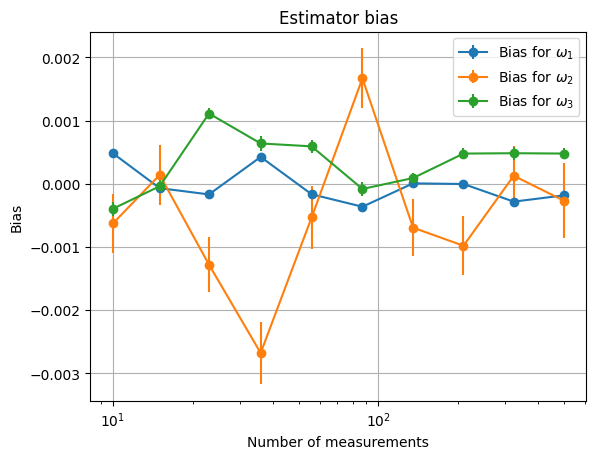

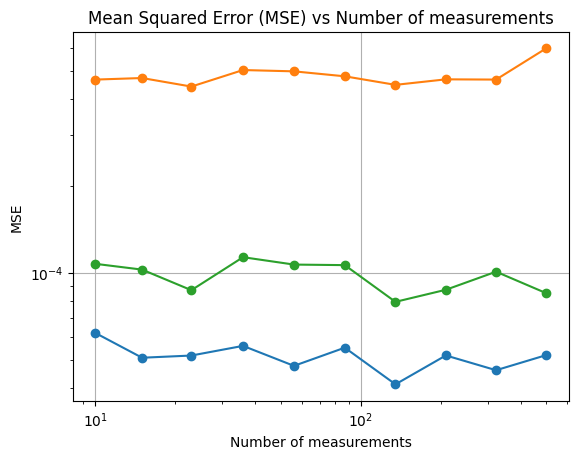

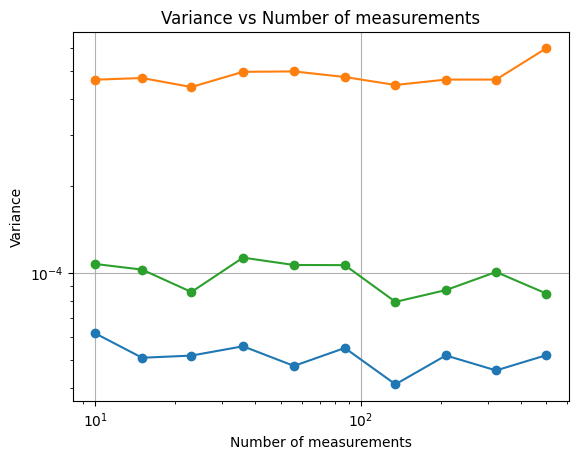

In [4]:
data = data_19_ls
plt.plot(data[8], data[6], marker='o')
plt.semilogy()
plt.semilogx()
plt.xlabel("Number of measurements")
plt.ylabel("Infidelity")
plt.title("Infidelity between inverse of Fisher information and covariance matrix")
plt.grid()
plt.show()

plt.plot(data[8], np.abs([x[0] for x in data[3]]), marker = 'o', label = "Eigenvalue 1")
plt.plot(data[8], np.abs([x[1] for x in data[3]]), marker = 'o', label = "Eigenvalue 2")
plt.plot(data[8], np.abs([x[2] for x in data[3]]), marker = 'o', label = "Eigenvalue 3")
plt.legend()
plt.semilogy()
plt.semilogx()
plt.xlabel("Number of measurements")
plt.ylabel("Eigenvalues")
plt.title("Eigenvalues of covariance matrix minus inverse of Fisher information matrix")
plt.grid()
plt.show()

plt.plot(data[8], data[5], marker='o')
plt.semilogy()
plt.semilogx()
plt.xlabel("Number of measurements")
plt.ylabel("Trace")
plt.title("Trace of inverse of Fisher information matrix")
plt.grid()
plt.show()

for i in range(data[0].shape[1]):
    plt.errorbar(data[8], data[0][:,i], yerr = data[11][:,i], label = f"Bias for $\omega_{i+1}$", marker = 'o')
plt.semilogx()
#plt.semilogy()
plt.xlabel("Number of measurements")
plt.ylabel("Bias")
plt.title("Estimator bias")
plt.legend()
plt.grid()
plt.show()

plt.plot(data[8], data[9], marker = 'o')
plt.xlabel("Number of measurements")
plt.ylabel("MSE")
plt.semilogy()
plt.semilogx()
plt.title("Mean Squared Error (MSE) vs Number of measurements")
plt.grid()
plt.show()

plt.plot(data[8], data[11], marker = 'o')
plt.xlabel("Number of measurements")
plt.ylabel("Variance")
plt.semilogy()
plt.semilogx()
plt.title("Variance vs Number of measurements")
plt.grid()
plt.show()

Data trotter least squares 20 (same parameters as paper with omega = beta = 10)

In [5]:
data_20_ls = load_npy('C:/Users/alexg/python_scripts/corrected_FI_code/trotter_least_squares/data_trotter_least_squares_0.01/data_trotter_20_least_squares_1')

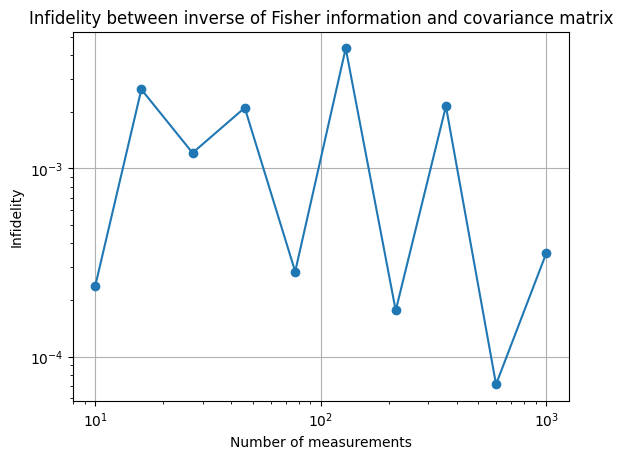

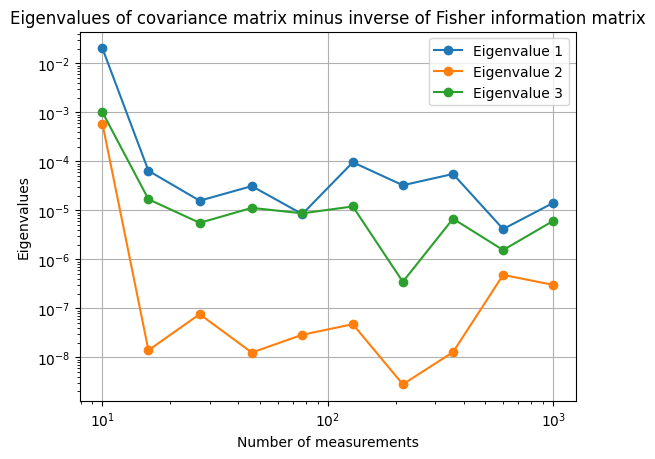

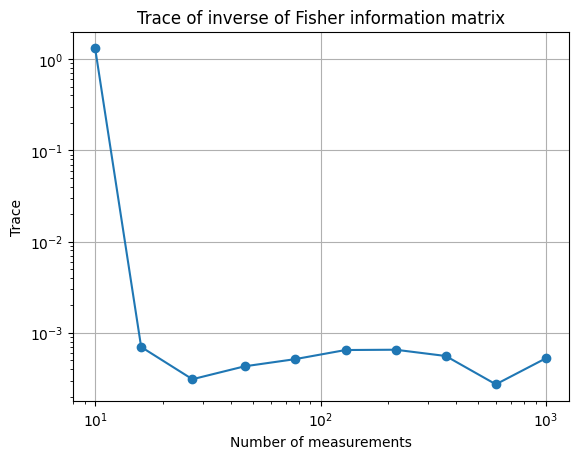

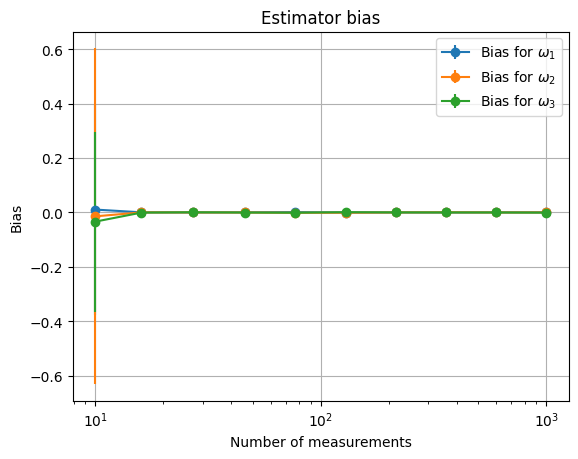

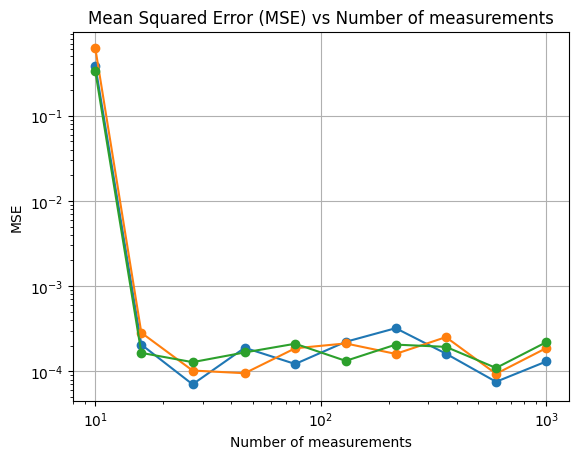

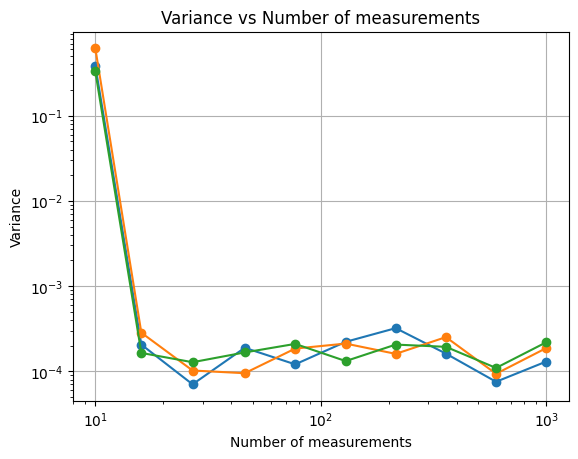

In [6]:
data = data_20_ls
plt.plot(data[8], data[6], marker='o')
plt.semilogy()
plt.semilogx()
plt.xlabel("Number of measurements")
plt.ylabel("Infidelity")
plt.title("Infidelity between inverse of Fisher information and covariance matrix")
plt.grid()
plt.show()

plt.plot(data[8], np.abs([x[0] for x in data[3]]), marker = 'o', label = "Eigenvalue 1")
plt.plot(data[8], np.abs([x[1] for x in data[3]]), marker = 'o', label = "Eigenvalue 2")
plt.plot(data[8], np.abs([x[2] for x in data[3]]), marker = 'o', label = "Eigenvalue 3")
plt.legend()
plt.semilogy()
plt.semilogx()
plt.xlabel("Number of measurements")
plt.ylabel("Eigenvalues")
plt.title("Eigenvalues of covariance matrix minus inverse of Fisher information matrix")
plt.grid()
plt.show()

plt.plot(data[8], data[5], marker='o')
plt.semilogy()
plt.semilogx()
plt.xlabel("Number of measurements")
plt.ylabel("Trace")
plt.title("Trace of inverse of Fisher information matrix")
plt.grid()
plt.show()

for i in range(data[0].shape[1]):
    plt.errorbar(data[8], data[0][:,i], yerr = data[11][:,i], label = f"Bias for $\omega_{i+1}$", marker = 'o')
plt.semilogx()
#plt.semilogy()
plt.xlabel("Number of measurements")
plt.ylabel("Bias")
plt.title("Estimator bias")
plt.legend()
plt.grid()
plt.show()

plt.plot(data[8], data[9], marker = 'o')
plt.xlabel("Number of measurements")
plt.ylabel("MSE")
plt.semilogy()
plt.semilogx()
plt.title("Mean Squared Error (MSE) vs Number of measurements")
plt.grid()
plt.show()

plt.plot(data[8], data[11], marker = 'o')
plt.xlabel("Number of measurements")
plt.ylabel("Variance")
plt.semilogy()
plt.semilogx()
plt.title("Variance vs Number of measurements")
plt.grid()
plt.show()

Data trotter least squares 21 (same parameters and method as paper with w = [ 0.02040919, -0.02555665,  0.00418099])

In [7]:
data_21_ls = load_npy('C:/Users/alexg/python_scripts/corrected_FI_code/trotter_least_squares/data_trotter_least_squares_0.01/data_trotter_21_least_squares_1')

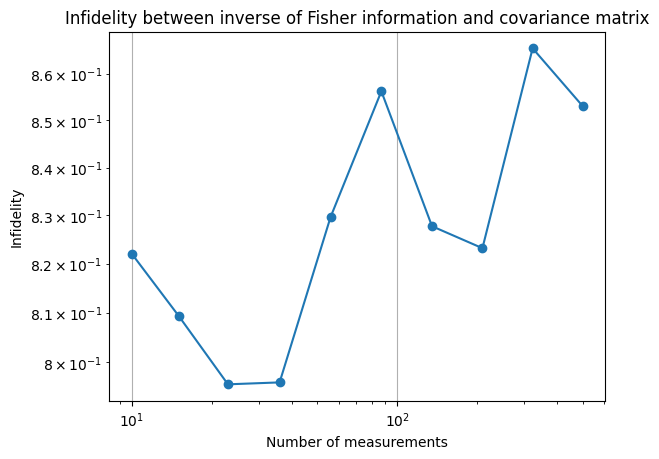

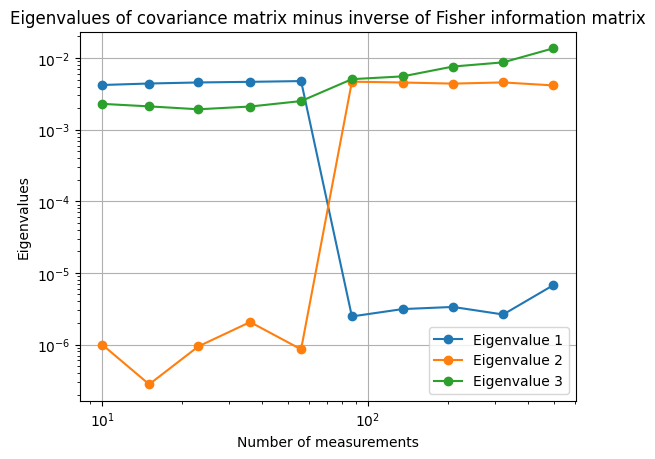

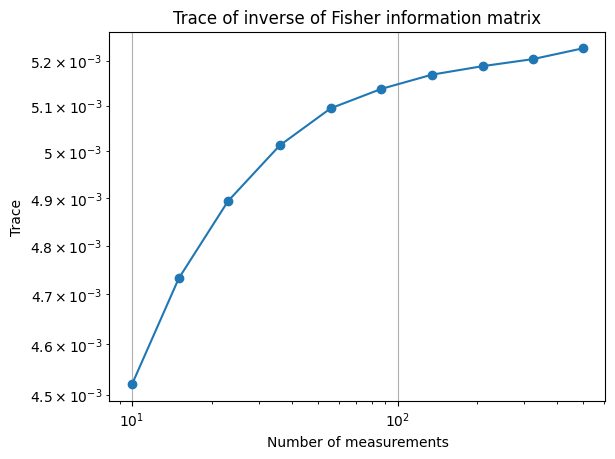

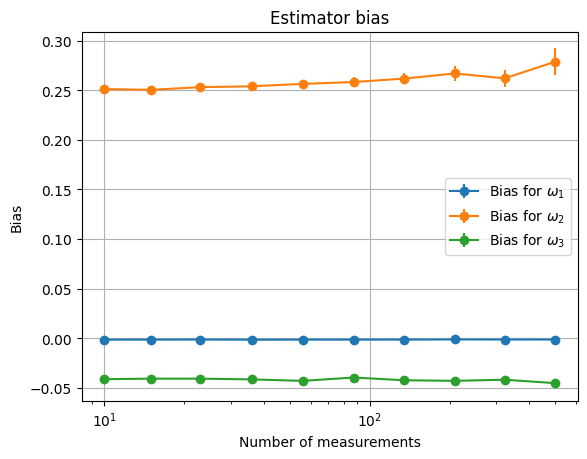

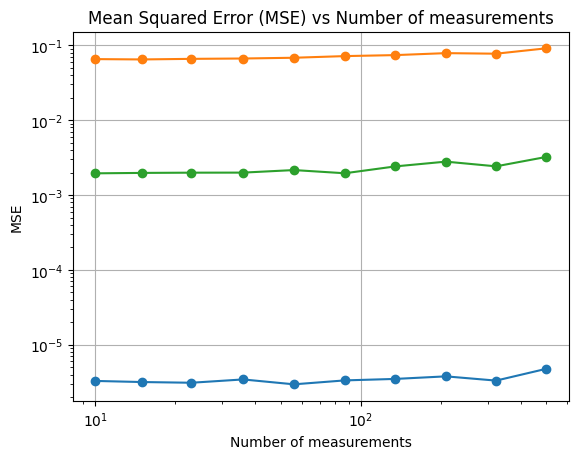

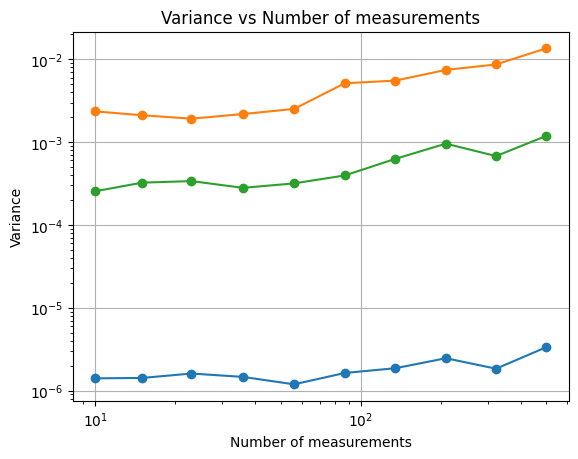

In [8]:
data = data_21_ls
plt.plot(data[8], data[6], marker='o')
plt.semilogy()
plt.semilogx()
plt.xlabel("Number of measurements")
plt.ylabel("Infidelity")
plt.title("Infidelity between inverse of Fisher information and covariance matrix")
plt.grid()
plt.show()

plt.plot(data[8], np.abs([x[0] for x in data[3]]), marker = 'o', label = "Eigenvalue 1")
plt.plot(data[8], np.abs([x[1] for x in data[3]]), marker = 'o', label = "Eigenvalue 2")
plt.plot(data[8], np.abs([x[2] for x in data[3]]), marker = 'o', label = "Eigenvalue 3")
plt.legend()
plt.semilogy()
plt.semilogx()
plt.xlabel("Number of measurements")
plt.ylabel("Eigenvalues")
plt.title("Eigenvalues of covariance matrix minus inverse of Fisher information matrix")
plt.grid()
plt.show()

plt.plot(data[8], data[5], marker='o')
plt.semilogy()
plt.semilogx()
plt.xlabel("Number of measurements")
plt.ylabel("Trace")
plt.title("Trace of inverse of Fisher information matrix")
plt.grid()
plt.show()

for i in range(data[0].shape[1]):
    plt.errorbar(data[8], data[0][:,i], yerr = data[11][:,i], label = f"Bias for $\omega_{i+1}$", marker = 'o')
plt.semilogx()
#plt.semilogy()
plt.xlabel("Number of measurements")
plt.ylabel("Bias")
plt.title("Estimator bias")
plt.legend()
plt.grid()
plt.show()

plt.plot(data[8], data[9], marker = 'o')
plt.xlabel("Number of measurements")
plt.ylabel("MSE")
plt.semilogy()
plt.semilogx()
plt.title("Mean Squared Error (MSE) vs Number of measurements")
plt.grid()
plt.show()

plt.plot(data[8], data[11], marker = 'o')
plt.xlabel("Number of measurements")
plt.ylabel("Variance")
plt.semilogy()
plt.semilogx()
plt.title("Variance vs Number of measurements")
plt.grid()
plt.show()

Data trotter least squares 22 (same parameters as paper with control, omega = beta = 1, w = [ 0.20409191, -0.2555665, 0.04180988])

In [9]:
data_22_ls = load_npy('C:/Users/alexg/python_scripts/corrected_FI_code/trotter_least_squares/data_trotter_least_squares_0.01/data_trotter_22_least_squares_1')

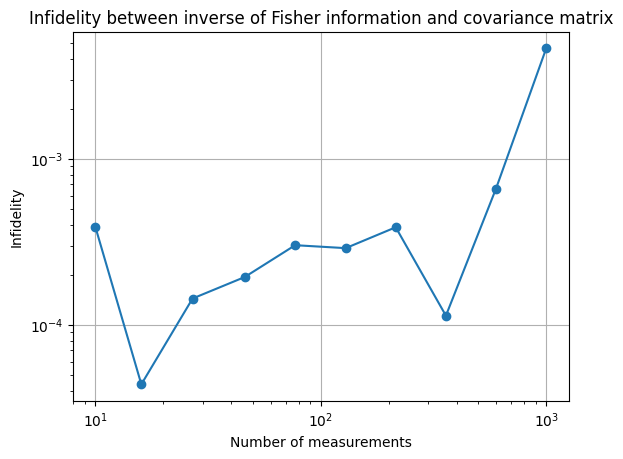

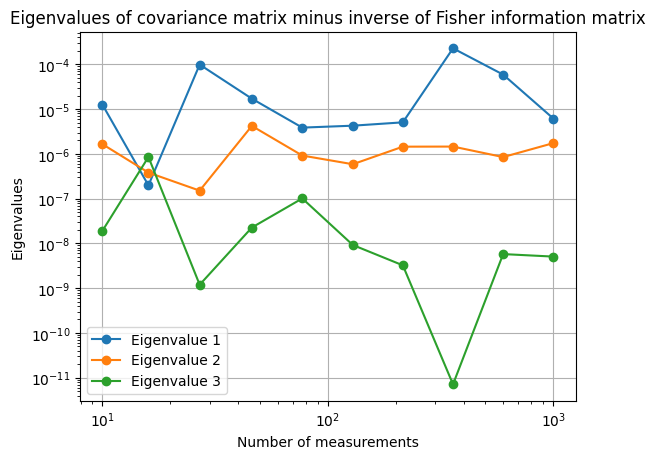

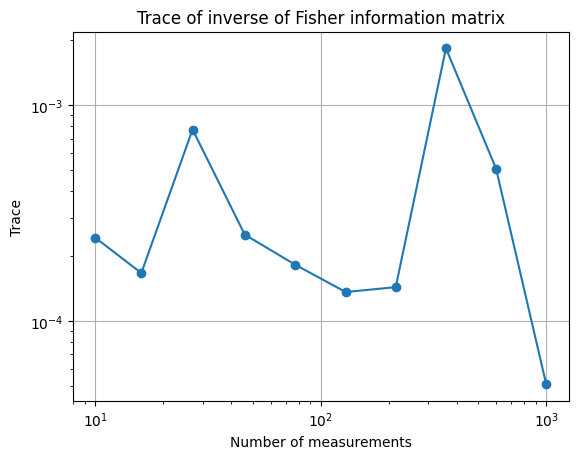

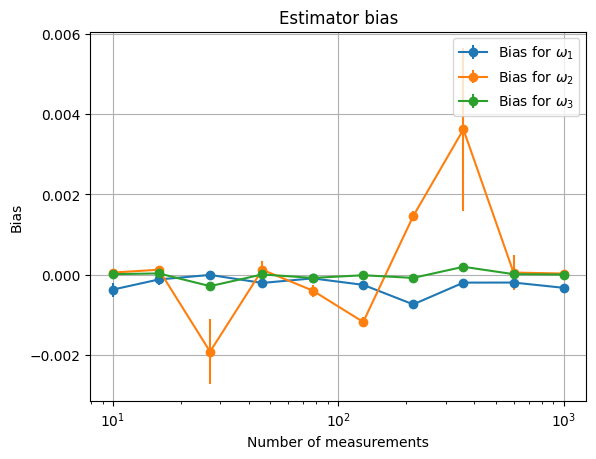

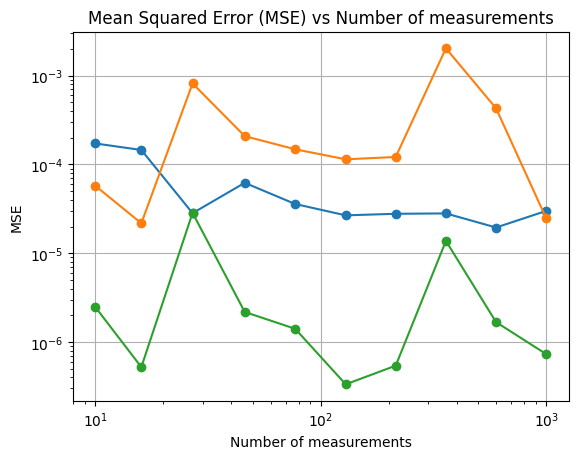

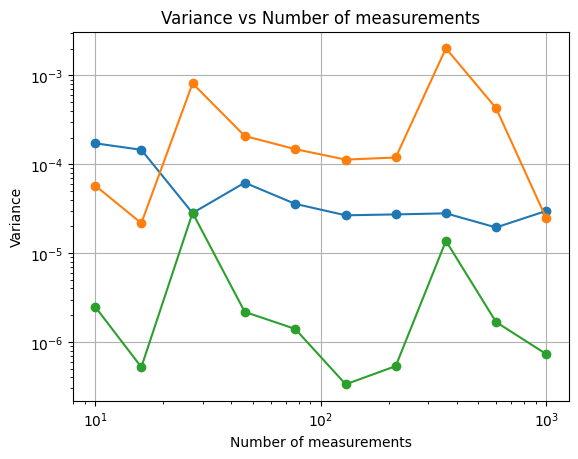

In [10]:
data = data_22_ls
plt.plot(data[8], data[6], marker='o')
plt.semilogy()
plt.semilogx()
plt.xlabel("Number of measurements")
plt.ylabel("Infidelity")
plt.title("Infidelity between inverse of Fisher information and covariance matrix")
plt.grid()
plt.show()

plt.plot(data[8], np.abs([x[0] for x in data[3]]), marker = 'o', label = "Eigenvalue 1")
plt.plot(data[8], np.abs([x[1] for x in data[3]]), marker = 'o', label = "Eigenvalue 2")
plt.plot(data[8], np.abs([x[2] for x in data[3]]), marker = 'o', label = "Eigenvalue 3")
plt.legend()
plt.semilogy()
plt.semilogx()
plt.xlabel("Number of measurements")
plt.ylabel("Eigenvalues")
plt.title("Eigenvalues of covariance matrix minus inverse of Fisher information matrix")
plt.grid()
plt.show()

plt.plot(data[8], data[5], marker='o')
plt.semilogy()
plt.semilogx()
plt.xlabel("Number of measurements")
plt.ylabel("Trace")
plt.title("Trace of inverse of Fisher information matrix")
plt.grid()
plt.show()

for i in range(data[0].shape[1]):
    plt.errorbar(data[8], data[0][:,i], yerr = data[11][:,i], label = f"Bias for $\omega_{i+1}$", marker = 'o')
plt.semilogx()
#plt.semilogy()
plt.xlabel("Number of measurements")
plt.ylabel("Bias")
plt.title("Estimator bias")
plt.legend()
plt.grid()
plt.show()

plt.plot(data[8], data[9], marker = 'o')
plt.xlabel("Number of measurements")
plt.ylabel("MSE")
plt.semilogy()
plt.semilogx()
plt.title("Mean Squared Error (MSE) vs Number of measurements")
plt.grid()
plt.show()

plt.plot(data[8], data[11], marker = 'o')
plt.xlabel("Number of measurements")
plt.ylabel("Variance")
plt.semilogy()
plt.semilogx()
plt.title("Variance vs Number of measurements")
plt.grid()
plt.show()

Data trotter least squares 23 (same parameters as paper with control, omega = 1, beta = 0, w = [ 0.20409191, -0.2555665, 0.04180988])

In [11]:
data_23_ls = load_npy('C:/Users/alexg/python_scripts/corrected_FI_code/trotter_least_squares/data_trotter_least_squares_0.01/data_trotter_23_least_squares_1')

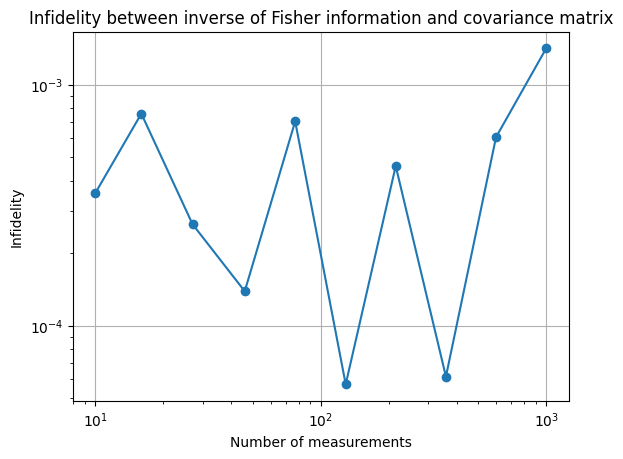

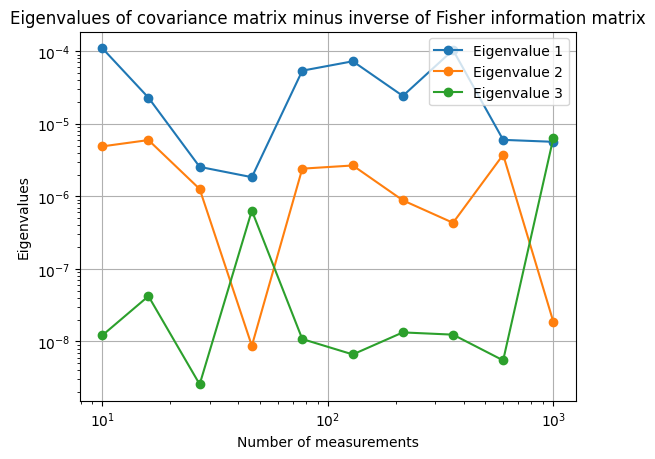

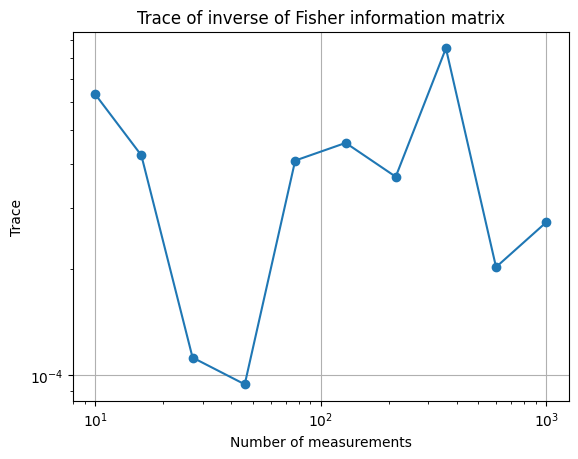

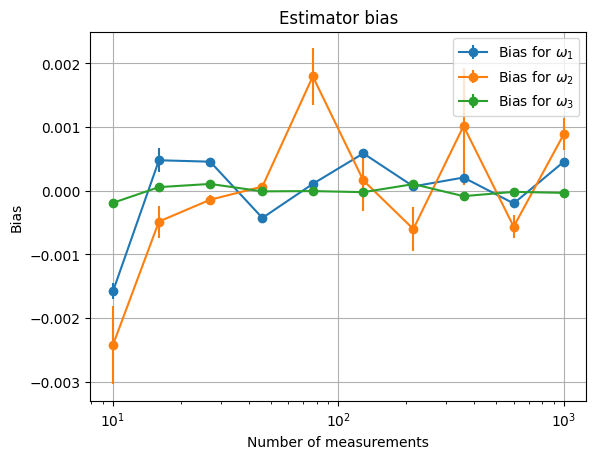

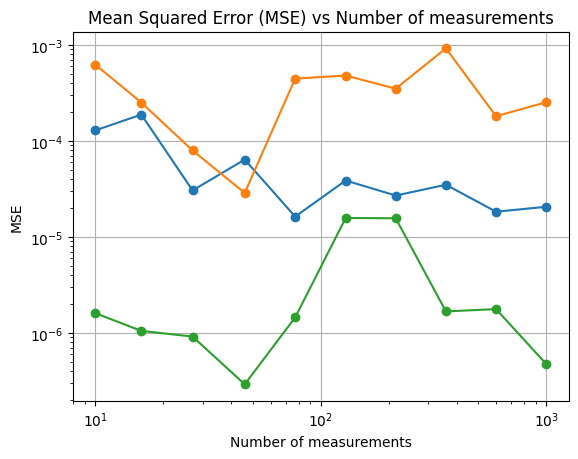

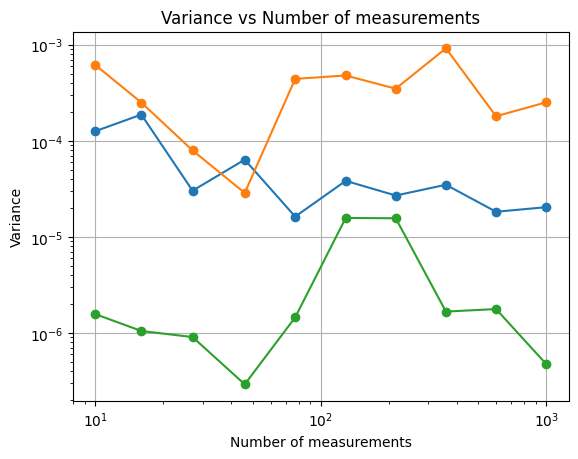

In [12]:
data = data_23_ls
plt.plot(data[8], data[6], marker='o')
plt.semilogy()
plt.semilogx()
plt.xlabel("Number of measurements")
plt.ylabel("Infidelity")
plt.title("Infidelity between inverse of Fisher information and covariance matrix")
plt.grid()
plt.show()

plt.plot(data[8], np.abs([x[0] for x in data[3]]), marker = 'o', label = "Eigenvalue 1")
plt.plot(data[8], np.abs([x[1] for x in data[3]]), marker = 'o', label = "Eigenvalue 2")
plt.plot(data[8], np.abs([x[2] for x in data[3]]), marker = 'o', label = "Eigenvalue 3")
plt.legend()
plt.semilogy()
plt.semilogx()
plt.xlabel("Number of measurements")
plt.ylabel("Eigenvalues")
plt.title("Eigenvalues of covariance matrix minus inverse of Fisher information matrix")
plt.grid()
plt.show()

plt.plot(data[8], data[5], marker='o')
plt.semilogy()
plt.semilogx()
plt.xlabel("Number of measurements")
plt.ylabel("Trace")
plt.title("Trace of inverse of Fisher information matrix")
plt.grid()
plt.show()

for i in range(data[0].shape[1]):
    plt.errorbar(data[8], data[0][:,i], yerr = data[11][:,i], label = f"Bias for $\omega_{i+1}$", marker = 'o')
plt.semilogx()
#plt.semilogy()
plt.xlabel("Number of measurements")
plt.ylabel("Bias")
plt.title("Estimator bias")
plt.legend()
plt.grid()
plt.show()

plt.plot(data[8], data[9], marker = 'o')
plt.xlabel("Number of measurements")
plt.ylabel("MSE")
plt.semilogy()
plt.semilogx()
plt.title("Mean Squared Error (MSE) vs Number of measurements")
plt.grid()
plt.show()

plt.plot(data[8], data[11], marker = 'o')
plt.xlabel("Number of measurements")
plt.ylabel("Variance")
plt.semilogy()
plt.semilogx()
plt.title("Variance vs Number of measurements")
plt.grid()
plt.show()